# TP3 — Aprendizaje no supervisado
**Grupo 22 · Diplomatura en Ciencia de Datos (FAMAF-UNC) · Mentoría 15**
## Mentoría 15: ¿Cuándo y dónde pescar centollas en el Canal Beagle?

**Consigna del TP3.** *Objetivo:* caracterizar los puntos de muestreo en base a la abundancia y las características de los ejemplares colectados, para responder las demandas de la municipalidad.

1. **Caracterizar** los puntos de muestreo considerando los ejemplares pescados. Se debe considerar la variabilidad temporal.
2. **Agrupar** los puntos de muestreo mediante técnicas de análisis no supervisado.
3. **Describir** la variabilidad temporal.
4. **Redactar una recomendación** para el gobierno local que tenga por objetivo la subsistencia del recurso pesquero a lo largo del tiempo.

Este documento desarrolla **los cuatro puntos**. Cada paso se presenta con el mismo formato: **Acción** (qué se hace), **Decisión** (qué se eligió y qué alternativas se descartaron) y **Justificación** (por qué).

## Resumen ejecutivo

**Pregunta.** ¿Qué recomendación puede darse al gobierno local para asegurar la persistencia del **centollón** en el Canal Beagle, a partir de lo capturado en trampas entre 1996 y 1998?

**Qué se hizo.**
1. **Caracterización (Punto 1):** de 13.114 registros se construyó una tabla de **57 puntos de muestreo** (localización + fecha) con 8.696 individuos de centollón, con indicadores de abundancia, composición por sexo, talla, madurez y estado reproductivo.
2. **Agrupamiento (Punto 2):** k-means con k = 4 sobre porcentaje de hembras, talla mediana y porcentaje de hembras ovígeras (55 puntos).
3. **Variabilidad temporal (Punto 3):** comparación de los tres octubres y de dos julios con pruebas no paramétricas sobre los puntos, y revisión de la calidad del registro reproductivo.
4. **Recomendación (Punto 4):** seis recomendaciones, cada una con su evidencia y su grado de respaldo.

**Resultados principales.**
- **El índice de abundancia (individuos por trampa) no se puede interpretar**: el número de individuos por punto no depende de las trampas (Spearman +0,002), por lo que el índice queda determinado por el número de trampas (−0,92). No se usó para estimar cuánto centollón hay.
- **Cuatro perfiles de puntos**, con estructura débil (silhouette 0,36): casi solo machos grandes (7 puntos, frágil), mayoría de machos con pocas hembras con huevos (11), mayoría de machos con hembras con huevos (15) y mayoría de hembras con huevos (22). Se asocian a la campaña (V de Cramér 0,51), pero ninguna campaña es de un solo grupo.
- **La talla aumenta entre octubre de 1996, 1997 y 1998** en machos (77,3 a 87,0 mm) y hembras (67,2 a 72,1 mm), y en 1998 el 99,4% de lo registrado es maduro. No se interpreta como mejora de la población: la causa no se puede determinar con los datos.
- **Hembras con huevos hubo en todas las campañas** (38% a 91% de las hembras evaluadas) y son el **26,4%** de lo registrado. No hay un patrón estacional estable entre años, y el registro de huevos es heterogéneo entre campañas.

**Recomendación (síntesis).** (1) Devolver vivas al agua a las hembras ovígeras, durante todo el año. (2) Re-muestrear con prioridad 7 sitios candidatos. (3) No fijar por ahora un calendario de veda con estos datos. (4) Seguir talla e inmaduros como indicadores de alerta. (5) Estandarizar el registro de los muestreos. (6) Analizar la centolla por separado.

**Límites.** Solo centollón; tres años y cuatro meses del año; **cada punto existe en una sola campaña** (lugar y tiempo confundidos); sin estimación de abundancia; sin datos sobre el efecto de las medidas. La recomendación se apoya en precaución, no en una caída medida de la población.

**Cómo ejecutar este notebook.** Se ejecuta de arriba abajo. Lee los datos de los repositorios públicos indicados en 1.1 (requiere conexión a internet) y genera tres archivos intermedios en la misma carpeta (`puntos_tp3.csv`, `individuos_tp3.csv`, `grupos_tp3.csv`) que usan los puntos siguientes. Las semillas están fijadas (`SEMILLA = 0`), por lo que los resultados son reproducibles.

## Punto 1 — Caracterización de los puntos de muestreo

### 1.0 Decisiones de diseño (se toman antes de tocar los datos)

Hay tres decisiones que condicionan todo el análisis posterior. Se dejan explícitas desde el principio porque cambiarlas modifica los resultados.

| # | Decisión | Elegida | Alternativas descartadas | Justificación |
|---|---|---|---|---|
| D1 | **Qué es un "punto de muestreo"** | La combinación **localización + fecha** (campaña). Si dentro del punto hubo lances de distinto esfuerzo, el esfuerzo del punto es la **suma** de los lances. | Localización + fecha + tipo (parte un mismo sitio en pedazos); solo localización (oculta que la fecha forma parte de la identidad del punto). | La consigna pide caracterizar *puntos*, no individuos ni lances. Un sitio pescado con varios lances es un único lugar. Tomar el esfuerzo de un solo lance infla el índice de abundancia (se muestra con un caso real en 1.5). |
| D2 | **Especie** | Solo **centollón** (*Paralomis granulosa*). | Ambas por separado; ambas juntas. | Es lo ya adoptado en el TP2. La centolla aporta pocos individuos por punto (244 de 9.105 individuos ubicados) y las métricas por punto serían inestables; mezclarla con el centollón combinaría dos poblaciones con tallas y biología distintas. **Límite que debe quedar escrito:** las conclusiones y la recomendación valen para el centollón, no para la centolla. |
| D3 | **Esfuerzo no identificable** | Los individuos cuyo `tipo` no declara cantidad de trampas **se excluyen de la tabla de puntos** (no se imputa). | Imputar con la mediana; conservarlos sin índice de abundancia. | El índice de abundancia es *individuos / trampas*. Imputar el denominador fabrica un dato que no existe en el registro. Se documenta cuántos individuos y qué puntos se pierden. |

### 1.1 Carga y unión de los datos

**Acción.** Se leen el archivo principal (`centollas_mentoria.csv`, repositorio de la mentora) y el suplemento de julio de 1997 (`jul97.csv`, repositorio del grupo) y se concatenan por filas.

**Decisión.** Se incluye julio de 1997. Se estandarizan los nombres de columnas (minúsculas, sin espacios) antes de unir.

**Justificación.** La mentora indicó que `jul97.csv` es opcional; se incorpora porque agrega una campaña completa (7 campañas en vez de 6) y es la única que cubre julio de 1997, lo que mejora la lectura temporal. El suplemento no tiene la columna `observaciones` ni las dos columnas vacías del archivo principal: al concatenar por nombre quedan como nulos, lo que no afecta a las variables que se usan.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.options.display.max_columns = 50
pd.options.display.width = 170

URL_PRINCIPAL = "https://raw.githubusercontent.com/luciabergagna-jpg/centoll/main/centollas_mentoria.csv"
URL_JUL97 = "https://raw.githubusercontent.com/Mariano-ds/centollas2026/main/datos/jul97.csv"

principal = pd.read_csv(URL_PRINCIPAL, sep=';', encoding='latin1')
jul97 = pd.read_csv(URL_JUL97, sep=';', encoding='utf-8-sig')
for d in (principal, jul97):
    d.columns = d.columns.str.strip().str.lower()

df = pd.concat([principal, jul97], ignore_index=True)
df = df.drop(columns=[c for c in df.columns if c.startswith('unnamed')])  # columnas vacías por separadores sobrantes

print(f"principal: {len(principal):,} filas | jul97: {len(jul97):,} filas | unión: {len(df):,} filas, {df.shape[1]} columnas")
assert len(df) == 13114

principal: 11,050 filas | jul97: 2,064 filas | unión: 13,114 filas, 18 columnas


### 1.2 Qué registros entran: embudo de filtrado

**Acción.** Se aplican tres filtros en orden y se cuenta cuántas filas se pierden en cada uno, y *cuáles* son.

1. **Sin `largo_caparazon`**: se descartan. *Justificación:* la talla es la variable biológica central de la caracterización (madurez, estructura de tallas); una fila sin talla no aporta a ningún indicador de ejemplares.
2. **Sin localización ni coordenadas** (las tres nulas a la vez): se descartan. *Justificación:* sin lugar no hay punto de muestreo, y el punto es la unidad de análisis (D1). Se exige que **al menos una** de las tres variables esté presente porque la localización textual permite identificar el punto aunque falten las coordenadas (enero y abril de 1996 no tienen coordenadas pero sí localización).
3. **Solo centollones** (D2).

Antes de aplicar el filtro 2 se clasifica el campo `tipo` (forma de muestreo) para saber qué se va a perder, porque el README del repositorio advierte que `desembarque` está *"sesgado a un tamaño determinado"* y que `muestreo de cubierta` corresponde a *"bichos no seleccionados por los pescadores"*.

In [2]:
def categoria_tipo(t):
    t = str(t).lower()
    if t.startswith('desembarque') or 'desembarque' in t:
        return 'desembarque'
    if t.startswith('muestreo de cubierta'):
        return 'muestreo de cubierta'
    if t.startswith('solo machos'):
        return 'solo machos'
    if 'wapisa' in t:
        return 'captura por la Wapisa'
    if 'trampa' in t or 'linea' in t or 'línea' in t:
        return 'captura con trampas/líneas'
    return 'otro'

df['categoria_tipo'] = df['tipo'].map(categoria_tipo)
print(df['categoria_tipo'].value_counts().to_string())

categoria_tipo
captura con trampas/líneas    9435
desembarque                   2587
muestreo de cubierta           730
solo machos                    271
captura por la Wapisa           75
otro                            16


In [3]:
n0 = len(df)

# Filtro 1: talla disponible
d1 = df[df['largo_caparazon'].notna()]
# Filtro 2: al menos una de localizacion / latitud / longitud
d2 = d1[d1[['latitud', 'longitud', 'localizacion']].notna().any(axis=1)]
# Filtro 3: centollones
d3 = d2[d2['especie'] == 2]

print(f"Filas iniciales                              : {n0:>7,}")
print(f"Filtro 1 (sin largo_caparazon)               : {len(d1):>7,}   (-{n0 - len(d1):,})")
print(f"Filtro 2 (sin localización ni coordenadas)   : {len(d2):>7,}   (-{len(d1) - len(d2):,})")
print(f"Filtro 3 (solo centollones)                  : {len(d3):>7,}   (-{len(d2) - len(d3):,})")

assert (len(d1), len(d2), len(d3)) == (13087, 9105, 8861)

print("\nFilas perdidas en el filtro 2, según forma de muestreo y campaña:")
perdidas = d1.drop(d2.index)
print(pd.crosstab(perdidas['categoria_tipo'], perdidas['fecha'], margins=True).to_string())

Filas iniciales                              :  13,114
Filtro 1 (sin largo_caparazon)               :  13,087   (-27)
Filtro 2 (sin localización ni coordenadas)   :   9,105   (-3,982)
Filtro 3 (solo centollones)                  :   8,861   (-244)

Filas perdidas en el filtro 2, según forma de muestreo y campaña:
fecha                       abril_96  ene_96  jul_96  jul_97  oct_97  oct_98   All
categoria_tipo                                                                    
captura con trampas/líneas       256      59       0     118       0       0   433
desembarque                        0     577       0     484     779     747  2587
muestreo de cubierta             500       0     175       0       0       0   675
otro                               0       0       0       0      16       0    16
solo machos                        0     271       0       0       0       0   271
All                              756     907     175     602     795     747  3982


**Resultado e interpretación.** El filtro 2 elimina 3.982 filas, y no son un conjunto cualquiera. La tabla muestra que:

- **Todas las filas de `desembarque` (2.587) y de `solo machos` (271) quedan fuera**, porque ninguna tiene localización ni coordenadas. El filtro de ubicación actúa, sin que nadie lo haya decidido, como filtro de *tipo de muestreo*.
- También se pierden **675 de las 730 filas de `muestreo de cubierta`** (500 de abril de 1996 y 175 de julio de 1996), que son justamente la forma de muestreo *no* sesgada por los pescadores, y **433 capturas con trampas** que no tienen ubicación (256 de abril de 1996, 118 de julio de 1997 y 59 de enero de 1996).
- Los efectos por campaña son desparejos: **abril de 1996 pierde 756 filas** y le queda un único punto; enero de 1996 pierde 907, sobre todo desembarques y solo machos.

**Decisión.** Se **acepta y se hace explícito**: la caracterización se hace con capturas con trampas que tienen ubicación, sin los desembarques ni los registros de solo machos.

**Justificación.** Los desembarques están sesgados por la selección de tamaño que hacen los pescadores (README), y "solo machos" registra únicamente un sexo; incluirlos distorsionaría talla, proporción de sexos y abundancia por punto. Sin ubicación, además, no hay punto de muestreo (D1). El costo es que la caracterización **no describe lo que se desembarca** sino lo que se captura en trampa, que se pierde la mayor parte del muestreo de cubierta y que abril de 1996 queda representado por un solo punto. Esto queda como límite del análisis.

### 1.3 Variables que se usan y limpieza de `huevos`

**Acción.** Se conservan solo las variables necesarias para caracterizar puntos: `fecha`, `rk`, `tipo`, `localizacion`, `latitud`, `longitud`, `profundidad`, `sexo`, `largo_caparazon`, `huevos`.

**Decisión.** Se dejan de lado `estado_caparazon`, `cirripedio`, `parasito`, `observaciones`, `ancho_caparazon`, `largo_quela` y `ancho_quela`.

**Justificación.** Para este punto se busca caracterizar abundancia, estructura de tallas, proporción de sexos, madurez y estado reproductivo. Las columnas de epibiontes, parásitos y pinza tienen alta proporción de nulos y no entran en esos indicadores; `ancho_caparazon` está casi vacío. No se borran del origen (`df`), solo no se usan.

**Limpieza de `huevos`.** La columna mezcla códigos numéricos con texto libre. Se revisan los valores no numéricos entre los centollones ubicados:

In [4]:
cols_uso = ['fecha', 'rk', 'tipo', 'localizacion', 'latitud', 'longitud',
            'profundidad', 'sexo', 'largo_caparazon', 'huevos', 'categoria_tipo']
w = d3[cols_uso].copy()

h = w['huevos'].dropna().astype(str)
no_num = h[pd.to_numeric(h, errors='coerce').isna()]
print("Valores de `huevos` no numéricos:")
print(no_num.value_counts().to_string())
print("\nSexo de esas filas:", w.loc[no_num.index, 'sexo'].value_counts().to_dict())
print("Machos con `huevos` informado (se ignoran, solo se evalúa a las hembras):",
      int(((w['sexo'] == 1) & w['huevos'].notna()).sum()))

Valores de `huevos` no numéricos:
huevos
conojos    2
7 en 1     1
po         1

Sexo de esas filas: {2: 4}
Machos con `huevos` informado (se ignoran, solo se evalúa a las hembras): 6


**Decisión.** Una sola corrección y una exclusión:

- `conojos` → **3**. Es un error de tipeo evidente de "con ojos", que en el diccionario del README corresponde al código 3 (*huevos con ojos*).
- `7 en 1` y `po` → **sin dato** (nulo). No hay forma de saber con certeza a qué código corresponden; no se les inventa valor.

**Justificación y diferencia con trabajos previos.** En el TP2 la fila `po` se eliminaba. Aquí se **conserva el individuo** y solo se anula el dato de huevos: eliminar la fila lo sacaría del conteo de abundancia aunque sea un animal realmente capturado, y el problema es únicamente que no se puede clasificar su estado reproductivo. Afecta a 2 hembras (`7 en 1` y `po`), que pasan a ser "no evaluadas" para las métricas reproductivas; las 2 filas `conojos` conservan el dato corregido.

In [5]:
w['huevos_txt'] = w['huevos'].astype(str).str.strip().replace({'conojos': '3'})
w['huevos_cod'] = pd.to_numeric(w['huevos_txt'], errors='coerce')   # 'po' y '7 en 1' quedan en NaN

print("Códigos de huevos tras la limpieza (todas las filas):")
print(w['huevos_cod'].value_counts(dropna=False).sort_index().to_string())

Códigos de huevos tras la limpieza (todas las filas):
huevos_cod
0.0      745
1.0     1315
2.0        1
3.0      301
4.0       39
5.0      261
6.0       97
7.0      107
30.0     473
40.0      10
NaN     5512


### 1.4 Esfuerzo de pesca: número de trampas

**Acción.** Se extrae el número de trampas del texto de `tipo` (por ejemplo, *"Captura total de 3 trampas"* → 3; *"Captura total de 2.5 trampas"* → 2,5).

**Decisión.** Se usa una función que busca el número **vinculado explícitamente** a la palabra *trampa* o *línea*. Para *línea* aplica la equivalencia **1 línea = 10 trampas** (dato de la mentora). Si el texto no declara cantidad (por ejemplo, *"Muestreo de cubierta 3"*, donde el 3 es un identificador de muestreo y no un número de trampas), el esfuerzo queda **nulo**.

**Justificación.** Una búsqueda genérica de "cualquier número" confundiría el identificador de un muestreo de cubierta o un código de punto (`wp 149`) con una cantidad de trampas. Vincular el número a la unidad evita ese error. En el subconjunto de trabajo no aparece ninguna captura declarada en líneas, así que la equivalencia no se llega a usar; se deja implementada por completitud.

In [6]:
def extraer_num_trampas(tipo_str):
    """Número de trampas declarado en `tipo`. 1 línea = 10 trampas. NaN si no se declara cantidad."""
    if pd.isna(tipo_str):
        return np.nan
    texto = str(tipo_str).lower()
    m_antes = re.search(r'(\d+\.?\d*)\s*(?:de\s*)?(trampa|línea|linea)', texto)      # "3 trampas", "2 líneas"
    m_despues = re.search(r'(trampa|línea|linea)s?\s*(?::\s*|de\s*)?(\d+\.?\d*)', texto)  # "trampas: 10"
    if m_antes:
        numero, unidad = float(m_antes.group(1)), m_antes.group(2)
    elif m_despues:
        unidad, numero = m_despues.group(1), float(m_despues.group(2))
    else:
        return np.nan
    return numero * 10.0 if unidad.startswith('l') else numero

w['num_trampas'] = w['tipo'].map(extraer_num_trampas)

print("Capturas declaradas en líneas (subconjunto de trabajo):", int(w['tipo'].str.contains('linea|línea', case=False).sum()))
sin_esf = w[w['num_trampas'].isna()]
print(f"\nIndividuos sin esfuerzo identificable: {len(sin_esf)}")
print(sin_esf.groupby(['localizacion', 'fecha', 'tipo'], dropna=False, observed=True).size().to_string())

Capturas declaradas en líneas (subconjunto de trabajo): 0

Individuos sin esfuerzo identificable: 165
localizacion  fecha   tipo                        
WP 59         oct_96  Muestreo de cubierta 3           55
NaN           jul_97  Captura total trampas wp 149    110


**Resultado.** Quedan sin esfuerzo identificable 165 individuos, de dos orígenes distintos:

- **110 individuos de `wp149` (julio de 1997)**, cuyo `tipo` es *"Captura total trampas wp 149"* sin cantidad de trampas y que además tienen la localización vacía. **Se pierde ese punto completo.**
- **55 individuos de `Muestreo de cubierta 3` en `WP 59` (octubre de 1996)**. Es otro método (animales no seleccionados por los pescadores, sin esfuerzo en trampas). **El punto `WP 59` no se pierde**: conserva sus 163 individuos capturados con 2 trampas.

**Decisión (aplicación de D3).** Se excluyen estos 165 individuos de la tabla de puntos.

**Justificación.** Sin trampas no se puede calcular el índice de abundancia, y mezclar en un mismo punto animales de cubierta con animales de trampa contaminaría el índice. Se pierden 165 de 8.861 individuos (1,9%) y un punto. Corrección de lo que se anticipó al elegir D3: se dijo que se perdían dos puntos, pero en realidad solo se pierde uno.

In [7]:
d = w[w['num_trampas'].notna()].copy()

print(f"Individuos para la tabla de puntos: {len(d):,}  (se excluyeron {len(w) - len(d)} de {len(w):,}; {100*(len(w)-len(d))/len(w):.1f}%)")
assert len(d) == 8696 and d['localizacion'].notna().all()   # sin esfuerzo se fueron también todos los nulos de localización

# ¿Cada (localización, fecha, tipo) es un único lance contiguo en el archivo original? Se verifica sobre TODAS las filas.
clave = df['fecha'].astype(str) + '|' + df['localizacion'].astype(str) + '|' + df['tipo'].astype(str)
bloque = (clave != clave.shift()).cumsum()
n_bloques = bloque.groupby(clave).nunique()
claves_trabajo = set(d['fecha'].astype(str) + '|' + d['localizacion'].astype(str) + '|' + d['tipo'].astype(str))
repetidas = [k for k in claves_trabajo if n_bloques[k] > 1]
print("(localización, fecha, tipo) del subconjunto que aparecen en más de un bloque separado:", repetidas)

Individuos para la tabla de puntos: 8,696  (se excluyeron 165 de 8,861; 1.9%)
(localización, fecha, tipo) del subconjunto que aparecen en más de un bloque separado: []


**Verificación que sustenta D1.** Sumar el esfuerzo de los distintos `tipo` de un punto solo es correcto si cada `tipo` repetido corresponde a **un único lance**. Si un mismo texto (por ejemplo, "10 trampas") apareciera en dos bloques separados del archivo, podrían ser dos lances iguales y habría que contarlo dos veces. El control anterior comprueba que **no ocurre** en los centollones del subconjunto: cada combinación localización-fecha-tipo es un bloque contiguo único.

### 1.5 Construcción de la tabla de puntos

**Acción.** Se define cada ejemplar con indicadores a nivel individuo y luego se agrega por `(localización, fecha)`.

**Indicadores por ejemplar** (ver justificaciones en la tabla siguiente):

| Indicador | Definición | Justificación |
|---|---|---|
| `maduro` | Macho con `largo_caparazon` ≥ **50,2 mm**; hembra con `largo_caparazon` ≥ **60,6 mm** | Umbrales de madurez sexual provistos por la mentora. Se aplican sobre el largo porque es la variable completa del dataset. |
| `hembra_evaluada` | Hembra con dato de `huevos` | El denominador correcto de cualquier porcentaje reproductivo. Contar toda hembra (tenga o no dato) subestimaría el porcentaje. |
| `hembra_ovigera` | Hembra evaluada con código de huevos 1, 2, 3, 30, 4, 40, 6 o 7 | Presencia de huevos o proceso de eclosión. Definición heredada del TP2. |
| `hembra_vulnerable` | Hembra evaluada ovígera **o** con código 5 (cápsulas vacías) | Una hembra recién eclosionada tiene el caparazón blando y es más susceptible al daño por manipulación. Definición heredada del TP2. |

**Indicadores por punto.** Individuos totales, machos y hembras; esfuerzo; **índice de abundancia relativa (IAR) = individuos / trampas** (total, machos, hembras); porcentaje de hembras; talla mediana (total y por sexo); porcentaje de maduros; hembras evaluadas, porcentaje de ovígeras y de vulnerables; profundidad mediana; coordenadas.

**Decisiones de agregación.**

- **Esfuerzo del punto = suma del esfuerzo de sus lances distintos** (D1).
- **Talla: mediana, no media.** La mediana es robusta a ejemplares extremos y a distribuciones asimétricas.
- **Profundidad: mediana** de las mediciones del punto, porque hay mediciones faltantes dentro de un mismo punto.
- **No se imputan datos faltantes.** Un punto sin dato de profundidad queda con nulo; un punto sin hembras evaluadas queda con nulo en los porcentajes reproductivos, en vez de 0 (que afirmaría "ninguna hembra ovígera" cuando en realidad "no se pudo evaluar").

In [8]:
COD_OVIGERAS = [1, 2, 3, 30, 4, 40, 6, 7]
COD_VULNERABLES = COD_OVIGERAS + [5]
UMBRAL_MADUREZ = {1: 50.2, 2: 60.6}   # mm de largo de caparazón; 1 = macho, 2 = hembra (mentora)

assert set(d['sexo'].unique()) <= {1, 2}

d['es_macho'] = d['sexo'] == 1
d['es_hembra'] = d['sexo'] == 2
d['maduro'] = d['largo_caparazon'] >= d['sexo'].map(UMBRAL_MADUREZ)
d['hembra_evaluada'] = d['es_hembra'] & d['huevos_cod'].notna()           # se calcula UNA vez, ya filtrada a hembras
d['hembra_ovigera'] = d['hembra_evaluada'] & d['huevos_cod'].isin(COD_OVIGERAS)
d['hembra_vulnerable'] = d['hembra_evaluada'] & d['huevos_cod'].isin(COD_VULNERABLES)

ORDEN_CAMPANAS = ['ene_96', 'abril_96', 'jul_96', 'oct_96', 'jul_97', 'oct_97', 'oct_98']
d['fecha'] = pd.Categorical(d['fecha'], categories=ORDEN_CAMPANAS, ordered=True)

# Esfuerzo del punto: suma del esfuerzo de cada lance (tipo) distinto
esf_lance = d.groupby(['localizacion', 'fecha', 'tipo'], observed=True)['num_trampas'].first().reset_index()
esfuerzo_punto = esf_lance.groupby(['localizacion', 'fecha'], observed=True)['num_trampas'].sum().rename('n_trampas')
n_lances = esf_lance.groupby(['localizacion', 'fecha'], observed=True).size().rename('n_lances')

key = ['localizacion', 'fecha']
g = d.groupby(key, observed=True)
puntos = g.agg(
    latitud=('latitud', 'mean'),
    longitud=('longitud', 'mean'),
    profundidad=('profundidad', 'median'),
    n_total=('rk', 'size'),
    n_machos=('es_macho', 'sum'),
    n_hembras=('es_hembra', 'sum'),
    n_maduros=('maduro', 'sum'),
    n_hembras_evaluadas=('hembra_evaluada', 'sum'),
    n_ovigeras=('hembra_ovigera', 'sum'),
    n_vulnerables=('hembra_vulnerable', 'sum'),
    largo_mediano=('largo_caparazon', 'median'),
).join(esfuerzo_punto).join(n_lances)

puntos['largo_mediano_macho'] = d[d['es_macho']].groupby(key, observed=True)['largo_caparazon'].median()
puntos['largo_mediano_hembra'] = d[d['es_hembra']].groupby(key, observed=True)['largo_caparazon'].median()

# Índices de abundancia relativa (individuos por trampa)
puntos['iar_total'] = puntos['n_total'] / puntos['n_trampas']
puntos['iar_macho'] = puntos['n_machos'] / puntos['n_trampas']
puntos['iar_hembra'] = puntos['n_hembras'] / puntos['n_trampas']

# Composición y estado reproductivo (NaN cuando el denominador es 0: "no evaluable", no "cero")
puntos['pct_hembras'] = 100 * puntos['n_hembras'] / puntos['n_total']
puntos['pct_maduros'] = 100 * puntos['n_maduros'] / puntos['n_total']
ev = puntos['n_hembras_evaluadas'].replace(0, np.nan)
puntos['pct_ovigeras'] = 100 * puntos['n_ovigeras'] / ev
puntos['pct_vulnerables'] = 100 * puntos['n_vulnerables'] / ev

puntos = puntos.reset_index().sort_values(['fecha', 'localizacion']).reset_index(drop=True)
print(f"Tabla de puntos: {puntos.shape[0]} puntos × {puntos.shape[1]} columnas")

Tabla de puntos: 57 puntos × 24 columnas


**Controles de consistencia.** Antes de interpretar nada, se verifica que la tabla sea coherente con los datos de origen. Si alguno falla, el notebook se detiene.

In [9]:
# 1) Se conservan todos los individuos
assert puntos['n_total'].sum() == len(d)
# 2) Machos + hembras = total
assert (puntos['n_machos'] + puntos['n_hembras'] == puntos['n_total']).all()
# 3) Hembras evaluadas <= hembras; ovígeras <= vulnerables <= evaluadas
assert (puntos['n_hembras_evaluadas'] <= puntos['n_hembras']).all()
assert (puntos['n_ovigeras'] <= puntos['n_vulnerables']).all() and (puntos['n_vulnerables'] <= puntos['n_hembras_evaluadas']).all()
# 4) Cada punto pertenece a una sola campaña
assert not puntos.duplicated('localizacion').any()
# 5) Las coordenadas son constantes dentro del punto (si no, la media enmascararía diferencias)
print("Coordenadas no constantes dentro de un punto:",
      int((d.groupby(key, observed=True)[['latitud', 'longitud']].nunique() > 1).any(axis=1).sum()))

print(f"Puntos: {len(puntos)} | individuos: {puntos['n_total'].sum():,} | puntos con >1 lance: {(puntos['n_lances'] > 1).sum()}")
print(f"Menor n de individuos en un punto: {puntos['n_total'].min()} | puntos con <10 hembras evaluadas: {(puntos['n_hembras_evaluadas'] < 10).sum()}")
assert len(puntos) == 57

Coordenadas no constantes dentro de un punto: 1
Puntos: 57 | individuos: 8,696 | puntos con >1 lance: 1
Menor n de individuos en un punto: 26 | puntos con <10 hembras evaluadas: 10


**Por qué D1 importa: caso real.** Un solo punto del subconjunto tiene lances de distinto esfuerzo: `E I. Martillo` (julio de 1996), con tres lances de 0,8, 1 y 1,5 trampas. Se compara el índice de abundancia con el esfuerzo de **un solo lance** (el criterio del notebook previo del grupo, que tomaba el primer valor) contra el esfuerzo **sumado** (el criterio adoptado):

In [10]:
multi = puntos[puntos['n_lances'] > 1][['localizacion', 'fecha', 'n_total', 'n_lances', 'n_trampas']].copy()
primer = d.groupby(key, observed=True)['num_trampas'].first().rename('esfuerzo_un_lance').reset_index()
multi = multi.merge(primer, on=key)
multi['iar_un_lance (incorrecto)'] = (multi['n_total'] / multi['esfuerzo_un_lance']).round(1)
multi['iar_suma_lances (adoptado)'] = (multi['n_total'] / multi['n_trampas']).round(1)
multi['sobreestimacion'] = (multi['iar_un_lance (incorrecto)'] / multi['iar_suma_lances (adoptado)']).round(2)
multi

,localizacion,fecha,n_total,n_lances,n_trampas,esfuerzo_un_lance,iar_un_lance (incorrecto),iar_suma_lances (adoptado),sobreestimacion
0,E I. Martillo,jul_96,539,3,3.3,1.0,539.0,163.3,3.3


In [11]:
# Las coordenadas de un punto con varios lances pueden diferir un poco entre lances; se promedian.
# Se mide cuánto: dispersión máxima (en km) entre las coordenadas de un mismo punto.
disp = d.groupby(key, observed=True).agg(lat_min=('latitud', 'min'), lat_max=('latitud', 'max'),
                                         lon_min=('longitud', 'min'), lon_max=('longitud', 'max'))
disp['dispersion_km'] = np.hypot((disp['lat_max'] - disp['lat_min']) * 111.2,
                                 (disp['lon_max'] - disp['lon_min']) * 111.2 * np.cos(np.radians(disp['lat_min'].abs())))
print(disp[disp['dispersion_km'] > 0][['dispersion_km']].round(2).to_string())
assert (disp['dispersion_km'] > 0).sum() == 1 and disp['dispersion_km'].max() < 1

                      dispersion_km
localizacion  fecha                
E I. Martillo jul_96           0.86

**Decisión sobre las coordenadas.** Las coordenadas del punto `E I. Martillo` difieren entre sus tres lances; se usa el **promedio**. La dispersión es de menos de 1 km, despreciable frente a la escala del canal, y en los 56 puntos restantes las coordenadas son constantes.

### 1.6 Tabla de puntos de muestreo (resultado del Punto 1)

Una fila por punto de muestreo. Esta es la tabla sobre la que se trabajará en los puntos siguientes.

In [12]:
vista = puntos.copy()
cols_redondeo = ['iar_total', 'iar_macho', 'iar_hembra', 'pct_hembras', 'pct_maduros',
                 'pct_ovigeras', 'pct_vulnerables', 'largo_mediano', 'largo_mediano_macho', 'largo_mediano_hembra']
vista[cols_redondeo] = vista[cols_redondeo].round(2)
vista[['latitud', 'longitud']] = vista[['latitud', 'longitud']].round(4)
vista

,localizacion,fecha,latitud,longitud,profundidad,n_total,n_machos,n_hembras,n_maduros,n_hembras_evaluadas,n_ovigeras,n_vulnerables,largo_mediano,n_trampas,n_lances,largo_mediano_macho,largo_mediano_hembra,iar_total,iar_macho,iar_hembra,pct_hembras,pct_maduros,pct_ovigeras,pct_vulnerables
0,frente bal. Ponsatti,ene_96,NaN,NaN,23.0,234,79,155,220,143,109,111,71.95,3.00,1,74.90,70.50,78.00,26.33,51.67,66.24,94.02,76.22,77.62
1,N Snipe al traves con la baliza p. de los indios,ene_96,NaN,NaN,43.0,191,45,146,191,136,97,130,76.60,4.00,1,85.10,75.25,47.75,11.25,36.50,76.44,100.00,71.32,95.59
2,S islote Belgrano/punta navarro,ene_96,NaN,NaN,27.0,121,28,93,120,91,78,86,79.30,2.00,1,86.00,77.00,60.50,14.00,46.50,76.86,99.17,85.71,94.51
3,SW Ilote Belgrano,ene_96,NaN,NaN,40.0,170,55,115,167,109,89,99,79.55,7.00,1,84.40,76.90,24.29,7.86,16.43,67.65,98.24,81.65,90.83
4,traves Snipe - P.Indios,ene_96,NaN,NaN,32.0,179,100,79,179,75,61,68,77.80,1.00,1,80.20,75.90,179.00,100.00,79.00,44.13,100.00,81.33,90.67
5,cerca de Haskesheska,abril_96,NaN,NaN,30.0,164,128,36,164,33,30,30,78.80,2.00,1,80.80,75.20,82.00,64.00,18.00,21.95,100.00,90.91,90.91
6,E I. Martillo,jul_96,-54.9034,-67.3543,30.0,539,448,91,508,88,26,26,72.90,3.30,3,73.90,64.90,163.33,135.76,27.58,16.88,94.25,29.55,29.55
7,entre Yunque y Martillo,jul_96,-54.8998,-67.3586,19.0,204,192,12,198,12,4,4,73.20,10.00,1,73.55,62.10,20.40,19.20,1.20,5.88,97.06,33.33,33.33
8,wp 30,jul_96,-54.8740,-67.7912,23.0,189,171,18,169,17,4,4,84.80,10.00,1,86.00,59.55,18.90,17.10,1.80,9.52,89.42,23.53,23.53
9,wp 32,jul_96,-54.9002,-67.3575,20.0,184,161,23,173,18,6,6,72.90,1.80,1,74.00,60.90,102.22,89.44,12.78,12.50,94.02,33.33,33.33


In [13]:
print("Valores faltantes por columna en la tabla de puntos:")
faltantes = puntos.isna().sum()
print(faltantes[faltantes > 0].to_string())
print("\nPuntos sin coordenadas, por campaña:")
print(puntos[puntos['latitud'].isna()].groupby('fecha', observed=True).size().to_string())

Valores faltantes por columna en la tabla de puntos:
latitud                 6
longitud                6
profundidad             1
largo_mediano_hembra    2
pct_ovigeras            2
pct_vulnerables         2

Puntos sin coordenadas, por campaña:
fecha
ene_96      5
abril_96    1


### 1.7 ¿Mide el IAR la abundancia? Control previo a interpretar

**Acción.** Antes de usar el índice (individuos / trampas) como medida de abundancia se verifica una condición: si el número de individuos registrados en un punto creciera con el esfuerzo, el IAR sería estable frente al número de trampas. Se mide la correlación de Spearman entre el esfuerzo (`n_trampas`) y, por un lado, el número de individuos registrados (`n_total`) y, por otro, el IAR.

**Justificación.** Un índice de abundancia relativa solo tiene sentido si lo capturado crece (aproximadamente) con el esfuerzo. Si no crece, el índice queda determinado por el denominador y refleja el protocolo de trabajo más que la abundancia del recurso.

In [14]:
from scipy.stats import spearmanr

r_n = spearmanr(puntos['n_trampas'], puntos['n_total'])
r_iar = spearmanr(puntos['n_trampas'], puntos['iar_total'])
print(f"Spearman esfuerzo vs individuos registrados (57 puntos): {r_n.correlation:+.3f}")
print(f"Spearman esfuerzo vs IAR                      (57 puntos): {r_iar.correlation:+.3f}")
print(f"\nIndividuos registrados por punto: mediana {puntos['n_total'].median():.0f} | "
      f"p10-p90 = {puntos['n_total'].quantile(.1):.0f}-{puntos['n_total'].quantile(.9):.0f} | "
      f"mín {puntos['n_total'].min()} | máx {puntos['n_total'].max()}")
print(f"Trampas por punto: mín {puntos['n_trampas'].min()} | mediana {puntos['n_trampas'].median()} | máx {puntos['n_trampas'].max()}")

filas = []
for c in ORDEN_CAMPANAS:
    g_ = puntos[puntos['fecha'] == c]
    if len(g_) >= 5:
        filas.append({'campaña': c, 'puntos': len(g_),
                      'rho(esfuerzo, individuos)': round(spearmanr(g_['n_trampas'], g_['n_total']).correlation, 2),
                      'rho(esfuerzo, IAR)': round(spearmanr(g_['n_trampas'], g_['iar_total']).correlation, 2)})
print("\nPor campaña (solo campañas con 5 o más puntos):")
print(pd.DataFrame(filas).to_string(index=False))

assert abs(r_n.correlation) < 0.1 and r_iar.correlation < -0.9

Spearman esfuerzo vs individuos registrados (57 puntos): +0.002
Spearman esfuerzo vs IAR                      (57 puntos): -0.920

Individuos registrados por punto: mediana 155 | p10-p90 = 91-190 | mín 26 | máx 539
Trampas por punto: mín 0.5 | mediana 3.0 | máx 10.0

Por campaña (solo campañas con 5 o más puntos):
campaña  puntos  rho(esfuerzo, individuos)  rho(esfuerzo, IAR)
 ene_96       5                       0.10               -0.90
 jul_96       7                      -0.02               -0.81
 oct_96       9                      -0.20               -0.97
 jul_97      10                      -0.36               -0.97
 oct_97      11                      -0.00               -0.92
 oct_98      14                      -0.03               -0.92


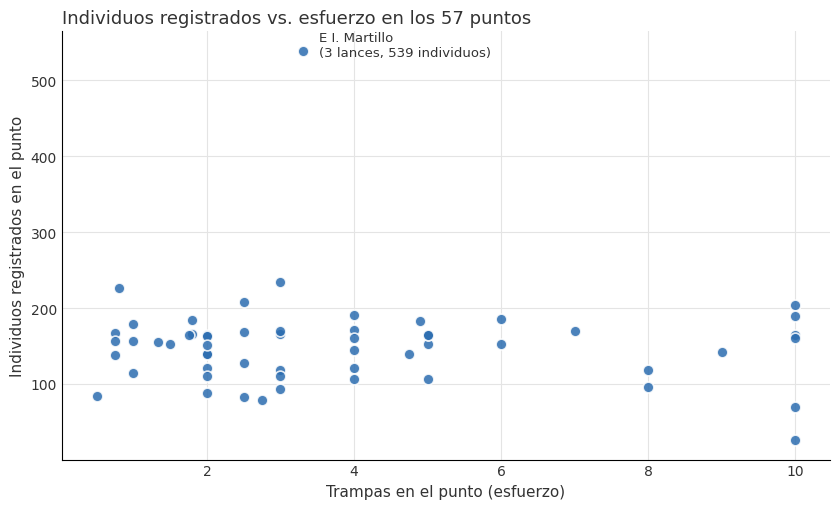

In [15]:
AZUL, TINTA, GRILLA = '#2B6CB0', '#333333', '#E4E4E4'
fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.scatter(puntos['n_trampas'], puntos['n_total'], s=60, color=AZUL, alpha=0.85, edgecolor='white', linewidth=1.2, zorder=3)
extremo = puntos.loc[puntos['n_total'].idxmax()]
ax.annotate(f"{extremo['localizacion']}\n({int(extremo['n_lances'])} lances, {int(extremo['n_total'])} individuos)",
            (extremo['n_trampas'], extremo['n_total']), xytext=(12, -4), textcoords='offset points', fontsize=9.5, color=TINTA)
ax.set_xlabel('Trampas en el punto (esfuerzo)', fontsize=11, color=TINTA)
ax.set_ylabel('Individuos registrados en el punto', fontsize=11, color=TINTA)
ax.set_title('Individuos registrados vs. esfuerzo en los 57 puntos', fontsize=13, loc='left', color=TINTA)
ax.grid(color=GRILLA, linewidth=0.8, zorder=0)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
ax.tick_params(length=0, colors=TINTA)
plt.tight_layout()
plt.show()

*Figura 1. Individuos registrados en cada uno de los 57 puntos según el número de trampas empleadas. Cada círculo es un punto de muestreo. Si lo registrado creciera con el esfuerzo, los círculos subirían hacia la derecha; se observa una nube sin tendencia.*

**Interpretación.** El número de individuos registrados **no guarda relación con el esfuerzo**: la correlación de Spearman es prácticamente cero (+0,002) aunque los puntos van de 0,5 a 10 trampas. La mayoría de los puntos registra entre 91 y 190 individuos (percentiles 10 y 90; mediana 155) sea cual sea el número de trampas. En consecuencia, el IAR queda determinado casi por completo por el denominador: su correlación con el esfuerzo es de −0,92, y es igual de fuerte dentro de cada campaña (tabla anterior). La excepción visible es `E I. Martillo`, con 539 individuos, pero repartidos en tres lances.

**Qué significa y qué no se puede afirmar.** Los datos solo permiten decir que *lo registrado por punto no crece con las trampas*. No permiten saber por qué. Una explicación posible es que en cada punto se haya medido un submuestreo de aproximadamente 100-200 individuos y no la captura completa; otra, que el esfuerzo declarado en `tipo` no se corresponda con el esfuerzo real. **Ninguna está respaldada por la documentación disponible** (el README no lo aclara), por lo que se deja como **pregunta abierta para la mentora**: *¿se midieron todos los individuos capturados en las N trampas o un submuestreo por punto?*

**Decisión.** Se **conservan** las columnas de IAR en la tabla de puntos (la consigna pide caracterizar abundancia y son el indicador que ya usa el grupo), pero **no se interpretan como abundancia del recurso** mientras no se aclare esa pregunta. Los indicadores de composición (porcentaje de hembras, talla, madurez, estado reproductivo) no dependen del esfuerzo, aunque suponen que lo medido en cada punto es representativo de lo capturado, supuesto que tampoco se puede verificar con los datos.

### 1.8 Variabilidad temporal

**Advertencia previa sobre el diseño de los datos.** Se comprueba si algún punto fue muestreado en más de una campaña:

In [16]:
fechas_por_loc = d.groupby('localizacion', observed=True)['fecha'].nunique()
print(f"Localizaciones muestreadas en más de una campaña: {(fechas_por_loc > 1).sum()} de {len(fechas_por_loc)}")

Localizaciones muestreadas en más de una campaña: 0 de 57


**Consecuencia.** Ningún punto se repite entre campañas: cada punto existe en **una sola** fecha. Por lo tanto, lo que se compara entre campañas **no es el mismo lugar medido varias veces**, sino **conjuntos distintos de lugares**. Una diferencia entre campañas puede deberse al tiempo, a que se muestrearon sitios distintos, o a ambas cosas, y con estos datos no se pueden separar. Esto es un límite estructural de los datos, no del análisis, y debe tenerse presente en la lectura de todo el trabajo.

**Acción.** Se resume cada campaña de dos formas complementarias:

- **Agregada** (suma de individuos sobre suma de trampas): describe la campaña como un todo, pero los puntos con más individuos pesan más.
- **Mediana de los puntos**: describe el punto "típico" de la campaña, sin que los puntos grandes dominen.

Cuando ambas coinciden, la conclusión es robusta; cuando difieren, se informa la diferencia. Se agrega la cantidad de puntos y el esfuerzo por campaña porque diferencias en el esfuerzo por lance podrían afectar la comparabilidad del índice de abundancia.

In [17]:
gc = puntos.groupby('fecha', observed=True)
camp = pd.DataFrame({
    'n_puntos': gc.size(),
    'n_individuos': gc['n_total'].sum(),
    'trampas_por_punto_mediana': gc['n_trampas'].median(),
    'IAR_agregado': gc['n_total'].sum() / gc['n_trampas'].sum(),
    'IAR_mediana_puntos': gc['iar_total'].median(),
    '%hembras_agregado': 100 * gc['n_hembras'].sum() / gc['n_total'].sum(),
    '%hembras_mediana_puntos': gc['pct_hembras'].median(),
    'largo_mediano_mm': d.groupby('fecha', observed=True)['largo_caparazon'].median(),
    '%maduros_agregado': 100 * gc['n_maduros'].sum() / gc['n_total'].sum(),
    'hembras_evaluadas': gc['n_hembras_evaluadas'].sum(),
    '%ovigeras_agregado': 100 * gc['n_ovigeras'].sum() / gc['n_hembras_evaluadas'].sum(),
    '%vulnerables_agregado': 100 * gc['n_vulnerables'].sum() / gc['n_hembras_evaluadas'].sum(),
}).round(2)
camp

,n_puntos,n_individuos,trampas_por_punto_mediana,IAR_agregado,IAR_mediana_puntos,%hembras_agregado,%hembras_mediana_puntos,largo_mediano_mm,%maduros_agregado,hembras_evaluadas,%ovigeras_agregado,%vulnerables_agregado
fecha,,,,,,,,,,,,
ene_96,5,895,3.00,52.65,60.50,65.70,67.65,76.4,97.99,554,78.34,89.17
abril_96,1,164,2.00,82.00,82.00,21.95,21.95,78.8,100.00,33,90.91,90.91
jul_96,7,1631,3.30,49.57,42.75,22.99,16.88,73.0,92.34,360,38.33,38.61
oct_96,9,1261,5.00,24.57,30.25,31.64,23.08,74.0,91.83,394,52.28,56.60
jul_97,10,1343,2.00,32.56,57.00,44.08,37.57,76.1,98.21,587,77.34,88.07
oct_97,11,1791,3.00,51.99,56.67,53.10,50.62,74.4,96.43,945,75.77,83.28
oct_98,14,1611,2.62,37.03,33.00,26.69,15.93,82.5,99.44,425,75.29,86.59


La talla mediana general mezcla dos cosas: la composición por sexo (los machos son más grandes) y el tamaño propio de cada sexo. Para no confundirlas se mira la talla **por sexo**:

In [18]:
talla_sexo = d.groupby(['fecha', 'sexo'], observed=True)['largo_caparazon'].median().unstack().rename(columns={1: 'machos (mm)', 2: 'hembras (mm)'})
talla_sexo['n_machos'] = d[d['es_macho']].groupby('fecha', observed=True).size()
talla_sexo['n_hembras'] = d[d['es_hembra']].groupby('fecha', observed=True).size()
talla_sexo.round(1)

sexo,machos (mm),hembras (mm),n_machos,n_hembras
fecha,,,,
ene_96,81.8,75.1,307,588
abril_96,80.8,75.2,128,36
jul_96,76.1,63.5,1256,375
oct_96,77.4,65.6,862,399
jul_97,81.2,71.5,751,592
oct_97,80.0,70.7,840,951
oct_98,85.7,71.9,1181,430


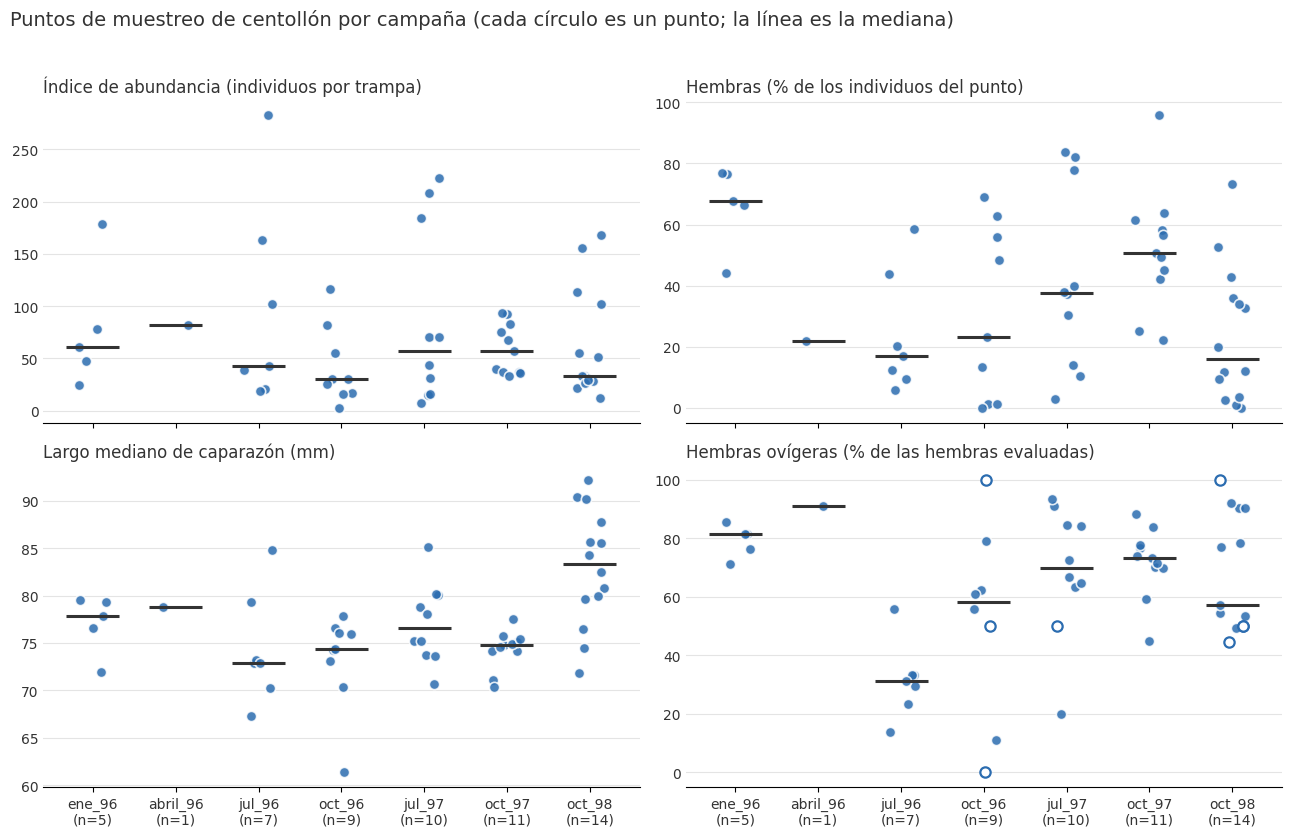

In [19]:
# Gráfico: cada punto de muestreo es un círculo; la línea negra marca la mediana de la campaña.
AZUL, TINTA, GRILLA = '#2B6CB0', '#333333', '#E4E4E4'
metricas = [
    ('iar_total',     'Índice de abundancia (individuos por trampa)'),
    ('pct_hembras',   'Hembras (% de los individuos del punto)'),
    ('largo_mediano', 'Largo mediano de caparazón (mm)'),
    ('pct_ovigeras',  'Hembras ovígeras (% de las hembras evaluadas)'),
]
etiquetas = [f"{c}\n(n={int((puntos['fecha'] == c).sum())})" for c in ORDEN_CAMPANAS]
rng = np.random.default_rng(0)

fig, axes = plt.subplots(2, 2, figsize=(13, 8.5), sharex=True)
for ax, (col, titulo) in zip(axes.ravel(), metricas):
    for i, c in enumerate(ORDEN_CAMPANAS):
        sub = puntos[(puntos['fecha'] == c) & puntos[col].notna()]
        x = i + rng.uniform(-0.18, 0.18, len(sub))
        # En el panel reproductivo, los puntos con <10 hembras evaluadas se dibujan huecos (proporción poco confiable)
        poco = (sub['n_hembras_evaluadas'] < 10).to_numpy() if col == 'pct_ovigeras' else np.zeros(len(sub), bool)
        ax.scatter(x[~poco], sub[col][~poco], s=55, color=AZUL, alpha=0.85, edgecolor='white', linewidth=1.2, zorder=3)
        ax.scatter(x[poco], sub[col][poco], s=55, facecolor='white', edgecolor=AZUL, linewidth=1.6, zorder=3)
        if len(sub):
            ax.hlines(sub[col].median(), i - 0.32, i + 0.32, color=TINTA, linewidth=2.2, zorder=4)
    ax.set_title(titulo, fontsize=12, loc='left', color=TINTA)
    ax.grid(axis='y', color=GRILLA, linewidth=0.8, zorder=0)
    for s in ('top', 'right', 'left'):
        ax.spines[s].set_visible(False)
    ax.tick_params(axis='y', length=0, labelsize=10, colors=TINTA)
    ax.set_xticks(range(len(ORDEN_CAMPANAS)))
    ax.set_xticklabels(etiquetas, fontsize=10, color=TINTA)
    ax.set_xlim(-0.6, len(ORDEN_CAMPANAS) - 0.4)
fig.suptitle('Puntos de muestreo de centollón por campaña (cada círculo es un punto; la línea es la mediana)',
             fontsize=14, x=0.01, ha='left', color=TINTA)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

*Figura 2. Cuatro indicadores de los 57 puntos de muestreo de centollón, por campaña. Cada círculo es un punto; la línea negra es la mediana de los puntos de la campaña; n es la cantidad de puntos. En el cuarto panel, los círculos huecos son puntos con menos de 10 hembras evaluadas, cuyo porcentaje es poco confiable. Abril de 1996 tiene un solo punto, por lo que no permite estimar variabilidad.*

**Interpretación.**

- **La proporción de sexos es el indicador que más varía, y varía tanto entre puntos de una misma campaña como entre campañas.** En el agregado, las hembras son el 65,7% de los individuos en enero de 1996, entre 22% y 32% en abril, julio y octubre de 1996, 44,1% en julio de 1997, 53,1% en octubre de 1997 y 26,7% en octubre de 1998. Pero dentro de una campaña los puntos son muy distintos: en octubre de 1998 van de 0% a 73,2% de hembras, en octubre de 1997 de 22,1% a 95,7% y en julio de 1997 de 2,9% a 83,6%. La variación entre puntos de una campaña es del mismo orden que la variación entre campañas.
- **La talla depende del sexo.** Los machos miden más que las hembras en todas las campañas (medianas de 76,1 a 85,7 mm frente a 63,5 a 75,2 mm). La mediana general de octubre de 1998 (82,5 mm, la más alta) refleja que esa campaña tiene los machos más grandes (85,7 mm) y, además, mayoría de machos (73% de los individuos); no hay que leerla como "crecimiento" de la población.
- **Casi todo lo capturado es sexualmente maduro.** Con los umbrales de la mentora (50,2 mm en machos y 60,6 mm en hembras), el porcentaje de maduros por campaña está entre 91,8% y 100%. Es un indicador con muy poca variación entre campañas, lo que lo hace poco informativo para distinguir puntos.
- **El estado reproductivo de las hembras difiere entre campañas, pero sin patrón estacional claro.** El porcentaje de hembras ovígeras (sobre las evaluadas) es 38,3% en julio de 1996 y 52,3% en octubre de 1996, frente a 75,3%-78,3% en enero de 1996, julio de 1997, octubre de 1997 y octubre de 1998 (abril de 1996 muestra 90,9%, pero sobre solo 33 hembras). Julio de 1996 y julio de 1997 son el mismo mes de años distintos y tienen valores opuestos (38,3% y 77,3%), así que lo observado no se puede atribuir a la época del año. En 10 puntos (4 de octubre de 1996, 1 de julio de 1997 y 5 de octubre de 1998) hay menos de 10 hembras evaluadas.
- **El IAR varía mucho, pero no es interpretable como abundancia** (ver 1.7). A modo de ejemplo, en julio de 1997 el IAR agregado (32,6) y la mediana de los puntos (57,0) difieren mucho porque tres puntos con 8 a 10 trampas tienen IAR bajo (6,9 a 15,8) y tres con 0,75 trampas tienen IAR alto (184 a 223), exactamente el patrón que produce el denominador.

**Síntesis.** Con estos datos, **la variabilidad entre puntos domina sobre la variabilidad entre campañas**, y ambas están confundidas, porque cada punto existe en una sola campaña. Las diferencias más claras entre campañas están en la proporción de sexos y en el estado reproductivo; la talla se explica sobre todo por el sexo; la madurez casi no varía; y la abundancia no puede leerse con el índice disponible.

In [20]:
# Se guarda la tabla de puntos: es la entrada del Punto 2.
puntos.to_csv('puntos_tp3.csv', index=False)
print('puntos_tp3.csv guardado:', puntos.shape)

puntos_tp3.csv guardado: (57, 24)


In [21]:
# Se guardan también los individuos que componen la tabla de puntos: son la entrada del Punto 3.
cols_ind = ['localizacion', 'fecha', 'sexo', 'largo_caparazon', 'huevos_cod', 'maduro', 'hembra_evaluada', 'hembra_ovigera', 'hembra_vulnerable']
d[cols_ind].to_csv('individuos_tp3.csv', index=False)
print('individuos_tp3.csv guardado:', d[cols_ind].shape)

individuos_tp3.csv guardado: (8696, 9)


### 1.9 Resumen del Punto 1

**Qué se produjo.** La tabla `puntos` (1.6): **57 puntos de muestreo** de centollón, uno por combinación localización-fecha, con 24 columnas (ubicación, profundidad, esfuerzo, abundancia, composición por sexo, talla, madurez y estado reproductivo). Se construyó a partir de 8.696 individuos de los 13.114 registros iniciales.

**Decisiones tomadas.**

| Tema | Decisión |
|---|---|
| Unidad de análisis | Punto = localización + fecha; esfuerzo = suma de lances |
| Especie | Solo centollón |
| Filtros | Se requiere talla y al menos localización o coordenadas; quedan fuera desembarques y "solo machos" |
| Esfuerzo no identificable | Se excluye (165 individuos, 1 punto completo); no se imputa |
| `huevos` | `conojos` → 3; `7 en 1` y `po` → sin dato (el individuo se conserva) |
| Faltantes en la tabla | No se imputan: quedan como nulos |

**Límites que condicionan los puntos siguientes.**

1. **Cada punto pertenece a una sola campaña**: no se puede separar el efecto del lugar del efecto del tiempo.
2. **Cobertura desigual**: abril de 1996 tiene un solo punto; enero y abril de 1996 (6 puntos) no tienen coordenadas, lo que impide ubicarlos en un mapa o asignarlos a una zona.
3. **El IAR no es interpretable como abundancia** mientras no se aclare qué representa el número de individuos por punto.
4. **Solo centollón**: la recomendación no puede extenderse a la centolla.
5. **Caracterización de lo capturado en trampa**, no de lo desembarcado.
6. **Poca información reproductiva en algunos puntos**: 10 puntos con menos de 10 hembras evaluadas.

**Preguntas abiertas para la mentora.**

- ¿Se midieron todos los individuos capturados en cada punto o un submuestreo?
- ¿Cuántas trampas corresponden a `Captura total trampas wp 149` (julio de 1997)? De saberse, ese punto (110 individuos) volvería a la tabla.

**Pasa al Punto 2.** La tabla `puntos` es la entrada del agrupamiento. Allí se agrupa con los indicadores de composición, talla y estado reproductivo (no dependen del esfuerzo); el IAR queda afuera por lo visto en 1.7, y la madurez se usa solo para describir porque casi no varía.

## Punto 2 — Agrupar los puntos de muestreo (aprendizaje no supervisado)

**Consigna.** *Agrupar los puntos de muestreo mediante técnicas de análisis no supervisado.*

**Entrada.** La tabla `puntos` del Punto 1 (57 puntos de centollón, uno por localización + fecha), guardada como `puntos_tp3.csv`.

### 2.0 Decisiones de diseño

| # | Decisión | Elegida | Alternativas descartadas | Justificación |
|---|---|---|---|---|
| E1 | **Variables de agrupamiento** | `pct_hembras`, `largo_mediano` y `pct_ovigeras` (elección del grupo: composición por sexo, talla y estado reproductivo). | Agregar profundidad; agregar el IAR; incluir fecha o coordenadas. | Describen **qué se pescó** en cada punto, que es lo que pide la consigna. El IAR se deja afuera porque depende del esfuerzo declarado y no de lo registrado (ver 1.7). La fecha se deja afuera para que los grupos no nazcan del calendario: se cruza con la campaña **después** de agrupar (2.7). La profundidad y la ubicación se usan solo para **interpretar** los grupos. |
| E2 | **Estandarización** | z-score de cada variable. | Usar las variables en su escala original. | Las variables están en unidades distintas (porcentajes y milímetros). Sin estandarizar, la variable con mayor rango domina las distancias. |
| E3 | **Puntos sin hembras evaluadas** | Se **excluyen** del agrupamiento (no se imputa su % de ovígeras). | Imputar con la mediana; recortar a 0%. | Sin hembras con dato de huevos el porcentaje no existe. Imputarlo inventaría un valor. Se informan por separado. |
| E4 | **Puntos con pocas hembras evaluadas** | Se **conservan** pero se marcan, y se prueba la **sensibilidad** quitándolos (2.6). | Descartarlos de entrada. | Con menos de 10 hembras evaluadas el % de ovígeras es poco confiable, pero descartarlos achica una muestra ya pequeña. Se verifica si cambian el resultado. |
| E5 | **Método y número de grupos** | Se comparan **k-means** y **Ward (jerárquico)** para k = 2 a 7; la elección de k se justifica con varios criterios (2.3). | HDBSCAN. | Con 57 puntos y 3 variables no hay densidad suficiente para métodos basados en densidad. Ward y k-means buscan grupos compactos, adecuados para describir perfiles. |

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score)

pd.options.display.max_columns = 50
SEMILLA = 0
ORDEN_CAMPANAS = ['ene_96', 'abril_96', 'jul_96', 'oct_96', 'jul_97', 'oct_97', 'oct_98']
TINTA, GRILLA = '#333333', '#E4E4E4'
# Paleta categórica validada (ranuras 1-4); en gráficos de dispersión se agrega una forma de marcador distinta por grupo
COLORES = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']
MARCAS = ['o', 's', '^', 'D']

puntos = pd.read_csv('puntos_tp3.csv')
assert puntos.shape[0] == 57
VARS = ['pct_hembras', 'largo_mediano', 'pct_ovigeras']
puntos['pocas_hembras'] = puntos['n_hembras_evaluadas'] < 10
print(puntos.shape)

(57, 25)


### 2.1 Qué puntos entran al agrupamiento

**Acción.** Se cuentan los valores faltantes de las tres variables y se identifican los puntos con pocas hembras evaluadas.

**Decisión.** Se aplican E3 y E4.

In [23]:
print('Faltantes en las variables de agrupamiento:'); print(puntos[VARS].isna().sum().to_string())
print('\nPuntos sin % de ovígeras (sin hembras con dato de huevos):')
print(puntos.loc[puntos['pct_ovigeras'].isna(), ['localizacion', 'fecha', 'n_total', 'n_hembras', 'n_hembras_evaluadas']].to_string(index=False))
print('\nPuntos con menos de 10 hembras evaluadas (se conservan, marcados):', int(puntos['pocas_hembras'].sum()))
print(puntos.loc[puntos['pocas_hembras']].groupby('fecha', observed=True).size().to_string())

d = puntos.dropna(subset=VARS).reset_index(drop=True)
assert len(d) == 55
print('\nPuntos que se agrupan:', len(d))

Faltantes en las variables de agrupamiento:
pct_hembras      0
largo_mediano    0
pct_ovigeras     2

Puntos sin % de ovígeras (sin hembras con dato de huevos):
localizacion  fecha  n_total  n_hembras  n_hembras_evaluadas
       wp 60 oct_96      166          0                    0
      wp 238 oct_98       84          0                    0

Puntos con menos de 10 hembras evaluadas (se conservan, marcados): 10
fecha
jul_97    1
oct_96    4
oct_98    5

Puntos que se agrupan: 55


**Resultado e interpretación.** Se agrupan **55 de los 57 puntos**. Quedan afuera `wp 60` (octubre de 1996, 166 individuos) y `wp 238` (octubre de 1998, 84 individuos): **ninguno tiene hembras**, por lo que su porcentaje de ovígeras no existe. Son puntos con 0% de hembras, es decir, los más extremos en composición por sexo; excluirlos es una pérdida real y se tiene presente al interpretar los grupos (se pueden ubicar a posteriori en el grupo con menos hembras, pero eso no se hace aquí para no forzar una asignación).

Hay **10 puntos con menos de 10 hembras evaluadas** en el total; **8** de ellos entran al agrupamiento (los otros 2 son los anteriores). Se los distingue con círculos huecos en las figuras.

### 2.2 Relación entre las variables y estandarización

**Acción.** Se calcula la correlación de Spearman entre las tres variables y se estandarizan (E2).

**Justificación.** Si dos variables estuvieran muy correlacionadas, el agrupamiento las contaría dos veces. Se usa Spearman porque las variables son porcentajes acotados y no se asume linealidad.

In [24]:
print(d[VARS].corr(method='spearman').round(2).to_string())
print()
print(d[VARS].describe().round(1).to_string())
scaler = StandardScaler()
X = scaler.fit_transform(d[VARS])
assert np.allclose(X.mean(axis=0), 0, atol=1e-9)

               pct_hembras  largo_mediano  pct_ovigeras
pct_hembras           1.00          -0.44          0.47
largo_mediano        -0.44           1.00          0.14
pct_ovigeras          0.47           0.14          1.00

       pct_hembras  largo_mediano  pct_ovigeras
count         55.0           55.0          55.0
mean          38.4           76.9          63.5
std           25.9            5.6          23.9
min            0.9           61.4           0.0
25%           13.7           73.6          50.0
50%           37.9           75.7          70.0
75%           58.3           79.6          81.5
max           95.7           92.2         100.0


**Resultado e interpretación.** Las correlaciones son moderadas (|rho| entre 0,14 y 0,47): ninguna variable es redundante, y cada una aporta información propia. Dos relaciones tienen sentido biológico y ya estaban en el Punto 1: **cuantas más hembras, menor la talla mediana** (rho = −0,44, porque las hembras son más chicas) y **cuantas más hembras, mayor el porcentaje de ovígeras** (rho = +0,47). La talla refleja entonces en parte la composición por sexo; no es una medida independiente del tamaño de los individuos.

Tras estandarizar, cada variable tiene media 0 y desvío 1 (verificado en el código).

### 2.3 Elección del número de grupos (k)

**Acción.** Para k = 2 a 7 se ajustan k-means y Ward y se calculan cuatro criterios:

- **Silhouette** (más alto es mejor; cercano a 0 significa que los grupos se solapan).
- **Davies-Bouldin** (más bajo es mejor).
- **Calinski-Harabasz** (más alto es mejor).
- **Estabilidad por remuestreo**: se sacan 200 muestras con reposición, se reajusta k-means y se compara con el agrupamiento original (índice de Rand ajustado, ARI; 1 = idéntico, 0 = azar). Se informa la mediana y el percentil 10.

**Justificación.** Ningún criterio decide por sí solo. Silhouette y Calinski-Harabasz tienden a favorecer ciertos k según la forma de los datos, y con pocos puntos la estabilidad importa tanto como la separación.

In [25]:
rng = np.random.default_rng(SEMILLA)
filas = []
for k in range(2, 8):
    km = KMeans(k, n_init=50, random_state=SEMILLA).fit(X)
    wd = AgglomerativeClustering(k, linkage='ward').fit(X)
    aris = []
    for b in range(200):
        idx = rng.choice(len(X), len(X), replace=True)
        kb = KMeans(k, n_init=10, random_state=b).fit(X[idx])
        aris.append(adjusted_rand_score(km.labels_, kb.predict(X)))
    filas.append({'k': k,
                  'silhouette_kmeans': silhouette_score(X, km.labels_),
                  'silhouette_ward': silhouette_score(X, wd.labels_),
                  'davies_bouldin': davies_bouldin_score(X, km.labels_),
                  'calinski_harabasz': calinski_harabasz_score(X, km.labels_),
                  'ARI_kmeans_vs_ward': adjusted_rand_score(km.labels_, wd.labels_),
                  'estab_ARI_mediana': np.median(aris),
                  'estab_ARI_p10': np.percentile(aris, 10),
                  'tam_min_grupo': int(np.bincount(km.labels_).min())})
sel = pd.DataFrame(filas).set_index('k').round(2)
sel

,silhouette_kmeans,silhouette_ward,davies_bouldin,calinski_harabasz,ARI_kmeans_vs_ward,estab_ARI_mediana,estab_ARI_p10,tam_min_grupo
k,,,,,,,,
2,0.36,0.36,1.16,30.71,0.54,0.72,0.23,19
3,0.34,0.37,0.99,33.31,0.32,0.58,0.39,12
4,0.36,0.31,0.88,36.20,0.52,0.70,0.48,7
5,0.36,0.32,0.88,35.00,0.48,0.61,0.47,3
6,0.34,0.33,0.86,36.75,0.80,0.67,0.47,3
7,0.32,0.31,0.86,35.90,0.79,0.59,0.42,3


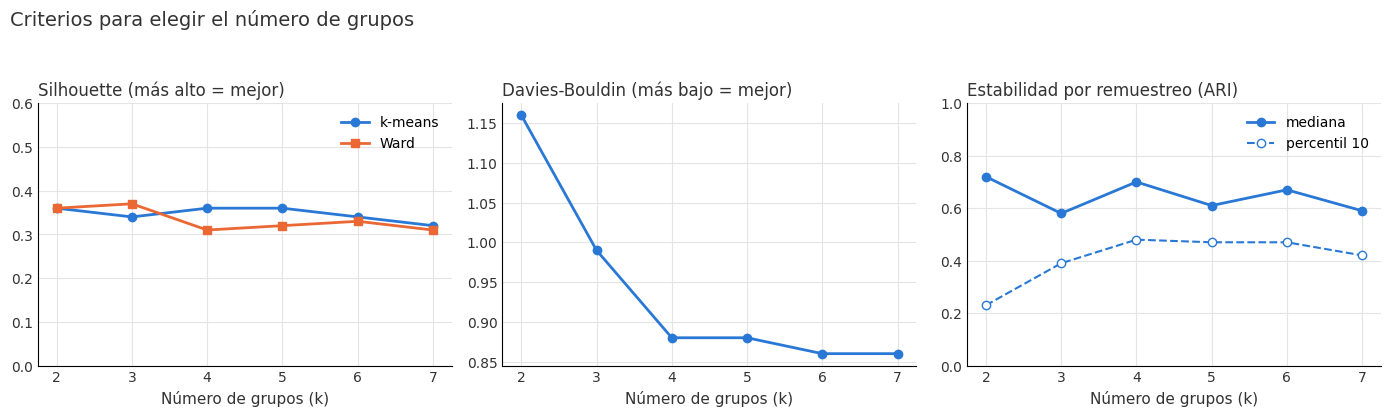

In [26]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4.2))
ks = sel.index
axs[0].plot(ks, sel['silhouette_kmeans'], marker='o', color=COLORES[0], lw=2, label='k-means')
axs[0].plot(ks, sel['silhouette_ward'], marker='s', color=COLORES[1], lw=2, label='Ward')
axs[0].set_title('Silhouette (más alto = mejor)', loc='left', fontsize=12, color=TINTA)
axs[0].set_ylim(0, 0.6); axs[0].legend(frameon=False, fontsize=10)
axs[1].plot(ks, sel['davies_bouldin'], marker='o', color=COLORES[0], lw=2)
axs[1].set_title('Davies-Bouldin (más bajo = mejor)', loc='left', fontsize=12, color=TINTA)
axs[2].plot(ks, sel['estab_ARI_mediana'], marker='o', color=COLORES[0], lw=2, label='mediana')
axs[2].plot(ks, sel['estab_ARI_p10'], marker='o', color=COLORES[0], lw=1.5, ls='--', mfc='white', label='percentil 10')
axs[2].set_title('Estabilidad por remuestreo (ARI)', loc='left', fontsize=12, color=TINTA)
axs[2].set_ylim(0, 1); axs[2].legend(frameon=False, fontsize=10)
for ax in axs:
    ax.set_xlabel('Número de grupos (k)', fontsize=11, color=TINTA)
    ax.grid(color=GRILLA, lw=0.8, zorder=0); ax.set_axisbelow(True)
    for s in ('top', 'right'): ax.spines[s].set_visible(False)
    ax.tick_params(length=0, colors=TINTA)
fig.suptitle('Criterios para elegir el número de grupos', x=0.01, ha='left', fontsize=14, color=TINTA)
fig.tight_layout(rect=(0, 0, 1, 0.93)); plt.show()

*Figura 3. Criterios para elegir el número de grupos, de k = 2 a 7, sobre los 55 puntos. Izquierda: silhouette de k-means y de Ward. Centro: índice de Davies-Bouldin de k-means. Derecha: estabilidad de k-means ante remuestreo (ARI entre el agrupamiento original y el de cada muestra con reposición; línea llena, mediana; línea punteada, percentil 10 de 200 repeticiones).*

**Interpretación.**

- **La separación entre grupos es débil en todos los k.** El silhouette se mantiene entre 0,31 y 0,37 sin una mejora clara con ningún k. Según la regla orientativa de Kaufman y Rousseeuw, valores entre 0,26 y 0,50 indican estructura débil. Esto significa que los puntos forman más bien un **continuo** que grupos naturales bien separados. Los grupos que se reporten son una **segmentación útil para describir**, no clases con fronteras nítidas.
- **k = 2** tiene silhouette igual al de k = 4 (0,36) pero es el peor en Davies-Bouldin (1,16) y su estabilidad es muy variable (percentil 10 = 0,23): en 1 de cada 10 remuestreos el agrupamiento casi no se parece al original.
- **k = 3** es el menos consistente entre métodos: k-means y Ward coinciden poco (ARI = 0,32).
- **k = 4** mejora Davies-Bouldin hasta 0,88 (de ahí en adelante casi no cambia), tiene la **mejor estabilidad en el percentil 10 (0,48)** y una mediana de 0,70, y ningún grupo es menor a 7 puntos.
- **k ≥ 5** no mejora los criterios y aparecen grupos de 3 puntos, demasiado chicos para describir.

**Decisión.** Se elige **k = 4** por equilibrio entre separación, estabilidad y tamaño de los grupos. Es una elección razonada, no la única posible: el silhouette por sí solo no la distingue de k = 2, 3 ni 5. La interpretación biológica de los grupos (2.5) es la que termina de justificarla.

### 2.4 Agrupamiento final

**Decisión.** k-means con **k = 4**. Los grupos se numeran de menor a mayor mediana de % de hembras, para que la numeración sea reproducible.

In [27]:
K = 4
km = KMeans(K, n_init=50, random_state=SEMILLA).fit(X)
orden = d.assign(c=km.labels_).groupby('c')['pct_hembras'].median().sort_values().index
mapa = {viejo: nuevo + 1 for nuevo, viejo in enumerate(orden)}
d['grupo'] = pd.Series(km.labels_).map(mapa).values
wd4 = AgglomerativeClustering(K, linkage='ward').fit(X).labels_
print('Puntos por grupo:'); print(d['grupo'].value_counts().sort_index().to_string())
print('\nAcuerdo k-means vs Ward (ARI):', round(adjusted_rand_score(d['grupo'], wd4), 2))
print('Silhouette:', round(silhouette_score(X, d['grupo']), 2))
d[['localizacion', 'fecha', 'grupo']].to_csv('grupos_tp3.csv', index=False)   # entrada del Punto 3

Puntos por grupo:
grupo
1     7
2    11
3    15
4    22

Acuerdo k-means vs Ward (ARI): 0.52
Silhouette: 0.36


### 2.5 Perfil de cada grupo

**Acción.** Se resume cada grupo con las medianas de las variables usadas y de variables **no usadas** en el agrupamiento (profundidad, IAR, talla de hembras), que sirven para interpretar los grupos sin haberlos moldeado.

In [28]:
perfil = d.groupby('grupo').agg(
    puntos=('grupo', 'size'),
    pct_hembras=('pct_hembras', 'median'),
    largo_mediano=('largo_mediano', 'median'),
    pct_ovigeras=('pct_ovigeras', 'median'),
    profundidad=('profundidad', 'median'),
    iar_total=('iar_total', 'median'),
    individuos=('n_total', 'sum'),
    pocas_hembras=('pocas_hembras', 'sum'),
).round(1)
perfil

,puntos,pct_hembras,largo_mediano,pct_ovigeras,profundidad,iar_total,individuos,pocas_hembras
grupo,,,,,,,,
1,7,9.5,85.6,50.0,27.0,31.0,798,4
2,11,12.5,73.2,31.1,28.0,42.8,2141,2
3,15,32.8,78.8,81.3,30.0,44.0,1841,2
4,22,62.6,74.3,75.1,31.0,52.2,3666,0


In [29]:
rangos = d.groupby('grupo')[VARS].agg(['min', 'max']).round(1)
rangos

pct_hembras       largo_mediano       pct_ovigeras       
              min   max           min   max          min    max
grupo                                                          
1             2.5  19.8          80.2  92.2         23.5   57.1
2             1.2  62.8          61.4  79.3          0.0   53.3
3             0.9  44.1          74.9  85.6         62.5  100.0
4            42.2  95.7          67.2  79.6         49.3   93.4

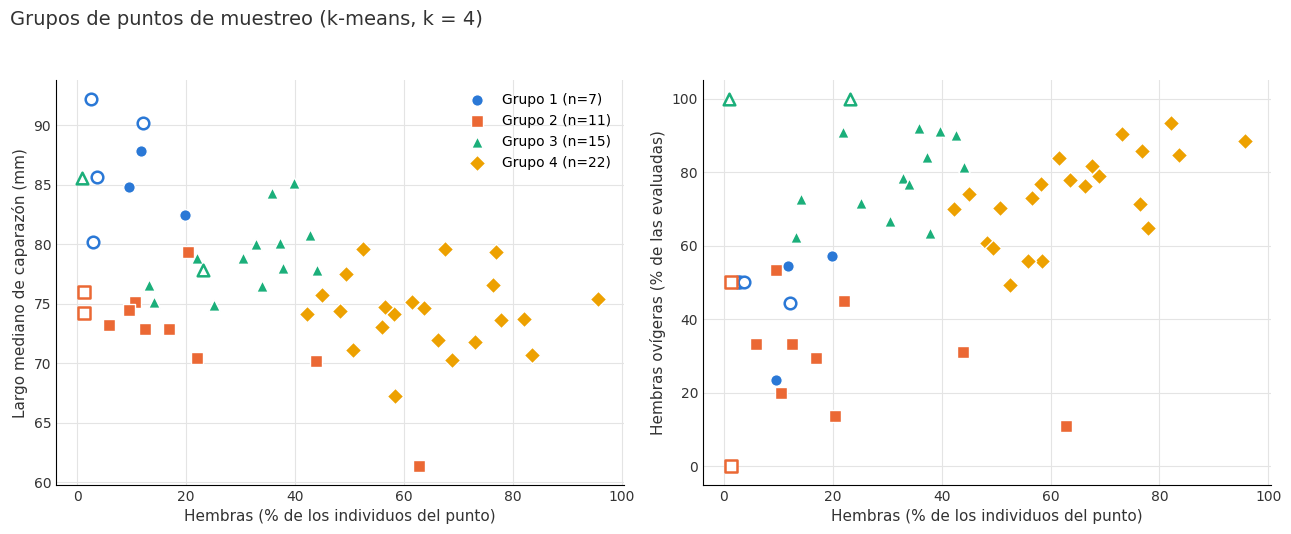

In [30]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5.4))
for ax, (xv, xl, yv, yl) in zip(axs, [('pct_hembras', 'Hembras (% de los individuos del punto)', 'largo_mediano', 'Largo mediano de caparazón (mm)'),
                                      ('pct_hembras', 'Hembras (% de los individuos del punto)', 'pct_ovigeras', 'Hembras ovígeras (% de las evaluadas)')]):
    for g in range(1, K + 1):
        s = d[d['grupo'] == g]
        pocas = s['pocas_hembras']
        ax.scatter(s.loc[~pocas, xv], s.loc[~pocas, yv], s=70, marker=MARCAS[g-1], color=COLORES[g-1],
                   edgecolor='white', linewidth=1.0, label=f'Grupo {g} (n={len(s)})', zorder=3)
        ax.scatter(s.loc[pocas, xv], s.loc[pocas, yv], s=70, marker=MARCAS[g-1], facecolor='white',
                   edgecolor=COLORES[g-1], linewidth=1.8, zorder=3)
    ax.set_xlabel(xl, fontsize=11, color=TINTA); ax.set_ylabel(yl, fontsize=11, color=TINTA)
    ax.grid(color=GRILLA, lw=0.8, zorder=0); ax.set_axisbelow(True)
    for s_ in ('top', 'right'): ax.spines[s_].set_visible(False)
    ax.tick_params(length=0, colors=TINTA)
axs[0].legend(frameon=False, fontsize=10, loc='upper right')
fig.suptitle('Grupos de puntos de muestreo (k-means, k = 4)', x=0.01, ha='left', fontsize=14, color=TINTA)
fig.tight_layout(rect=(0, 0, 1, 0.94)); plt.show()

*Figura 4. Los 55 puntos agrupados por k-means (k = 4). Cada marcador es un punto de muestreo; el color y la forma indican el grupo. Los marcadores huecos son puntos con menos de 10 hembras evaluadas, cuyo porcentaje de ovígeras es poco confiable. Izquierda: porcentaje de hembras y talla mediana. Derecha: porcentaje de hembras y porcentaje de hembras ovígeras.*

**Interpretación de los grupos.**

| Grupo | Puntos | Perfil | Hembras (mediana) | Talla mediana | Ovígeras (mediana) |
|---|---|---|---|---|---|
| 1 | 7 | **Casi solo machos, de talla grande** | 9,5% | 85,6 mm | 50,0%* |
| 2 | 11 | **Mayoría machos, talla menor, pocas hembras con huevos** | 12,5% | 73,2 mm | 31,1% |
| 3 | 15 | **Mayoría machos, hembras casi todas con huevos** | 32,8% | 78,8 mm | 81,3% |
| 4 | 22 | **Mayoría hembras, con huevos** | 62,6% | 74,3 mm | 75,1% |

\* En el grupo 1, 4 de los 7 puntos tienen menos de 10 hembras evaluadas, así que su 50% de ovígeras casi no es informativo.

- Los grupos se distinguen sobre todo por **cuántas hembras hay** (eje horizontal de la Figura 4). El grupo 4 es el único con mayoría de hembras (mínimo 42,2%); los otros tres son de mayoría de machos.
- **El grupo 2 es el que tiene menos hembras ovígeras** (31,1%; 8 de sus 11 puntos tienen 33% o menos). Con estos datos no se puede decir si refleja una época del año, un lugar o el estado real de las hembras, porque 8 de sus 11 puntos son de julio y octubre de 1996 (2.7).
- Los grupos 3 y 4 tienen un porcentaje de ovígeras parecido (81,3% y 75,1%) y se diferencian por la proporción de sexos (32,8% frente a 62,6% de hembras).
- **La profundidad mediana es casi la misma en los cuatro grupos** (27 a 31 m), aunque no se usó para agrupar: no hay indicio de que los grupos se asocien a la profundidad. El IAR mediano varía de 31 a 52, pero no se interpreta por lo visto en 1.7.

### 2.6 Robustez del agrupamiento

**Acción.** Se repite el agrupamiento (a) con Ward y (b) quitando los puntos con menos de 10 hembras evaluadas (E4), y se compara con el agrupamiento principal mediante el ARI en los puntos comunes.

In [31]:
# (a) Ward vs k-means ya calculado arriba. (b) sin puntos con pocas hembras evaluadas
firme = d[~d['pocas_hembras']].reset_index(drop=True)
Xf = StandardScaler().fit_transform(firme[VARS])
kmf = KMeans(K, n_init=50, random_state=SEMILLA).fit(Xf)
ari_sens = adjusted_rand_score(firme['grupo'], kmf.labels_)
print(f'Puntos que quedan: {len(firme)}')
print(f'Silhouette sin los {int(d.pocas_hembras.sum())} puntos con pocas hembras: {silhouette_score(Xf, kmf.labels_):.2f}')
print(f'ARI entre el agrupamiento principal y el de sensibilidad (en esos {len(firme)} puntos): {ari_sens:.2f}')
print('Tamaños de grupo (sensibilidad):', np.bincount(kmf.labels_).tolist())
print(f'ARI k-means vs Ward (k=4): {adjusted_rand_score(d.grupo, wd4):.2f}')
print('\nCruce principal (filas) vs sensibilidad (columnas):')
print(pd.crosstab(firme['grupo'], kmf.labels_).to_string())

Puntos que quedan: 47
Silhouette sin los 8 puntos con pocas hembras: 0.34
ARI entre el agrupamiento principal y el de sensibilidad (en esos 47 puntos): 0.70
Tamaños de grupo (sensibilidad): [3, 17, 8, 19]
ARI k-means vs Ward (k=4): 0.52

Cruce principal (filas) vs sensibilidad (columnas):
col_0  0   1  2   3
grupo              
1      0   2  1   0
2      2   0  7   0
3      0  13  0   0
4      1   2  0  19


**Interpretación.**

- **Ward** reproduce el agrupamiento solo en parte (ARI = 0,52): ambos métodos coinciden en la estructura general pero no en los límites exactos. Es lo esperable cuando los grupos no están bien separados (2.3).
- **Sin los puntos con pocas hembras evaluadas** (47 puntos), el agrupamiento se parece al principal (ARI = 0,70). Los grupos **2, 3 y 4 se reproducen**: los 13 puntos del grupo 3 caen juntos en un mismo grupo nuevo, 19 de los 22 del grupo 4 también, y 7 de los 9 restantes del grupo 2 también. El **grupo 1 es el frágil**: 4 de sus 7 puntos son de los que se quitan y los 3 que quedan se reparten.
- En consecuencia: los grupos 2, 3 y 4 son **robustos** a este cambio; el grupo 1 (machos grandes, 7 puntos) debe leerse como un **perfil extremo posible**, no como un grupo consolidado.

### 2.7 Cruce con la campaña, la profundidad y la ubicación

**Acción.** Con los grupos ya formados, se ve en qué campañas están sus puntos. Esto **no** se usó para agrupar, así que si aparece estructura temporal es un resultado y no una consecuencia del método.

In [32]:
cruce = pd.crosstab(d['grupo'], pd.Categorical(d['fecha'], ORDEN_CAMPANAS))
cruce.columns.name = 'campaña'
cruce

campaña,ene_96,abril_96,jul_96,oct_96,jul_97,oct_97,oct_98
grupo,,,,,,,
1,0,0,1,0,1,0,5
2,0,0,5,3,1,1,1
3,1,1,0,2,5,1,5
4,4,0,1,3,3,9,2


In [33]:
# Prueba de permutación: ¿los grupos están más asociados a la campaña de lo que daría el azar?
# Estadístico: V de Cramér.
def cramer_v(a, b):
    t = pd.crosstab(a, b).values.astype(float)
    exp = t.sum(1, keepdims=True) * t.sum(0, keepdims=True) / t.sum()
    chi2 = ((t - exp) ** 2 / exp).sum()
    return np.sqrt(chi2 / (t.sum() * (min(t.shape) - 1)))
obs = cramer_v(d['grupo'], d['fecha'])
rng = np.random.default_rng(SEMILLA)
perm = np.array([cramer_v(d['grupo'], rng.permutation(d['fecha'].values)) for _ in range(5000)])
print(f'V de Cramér observada: {obs:.2f} | percentil 95 de permutaciones: {np.percentile(perm, 95):.2f} | p aproximado: {(perm >= obs).mean():.4f}')

V de Cramér observada: 0.51 | percentil 95 de permutaciones: 0.41 | p aproximado: 0.0006


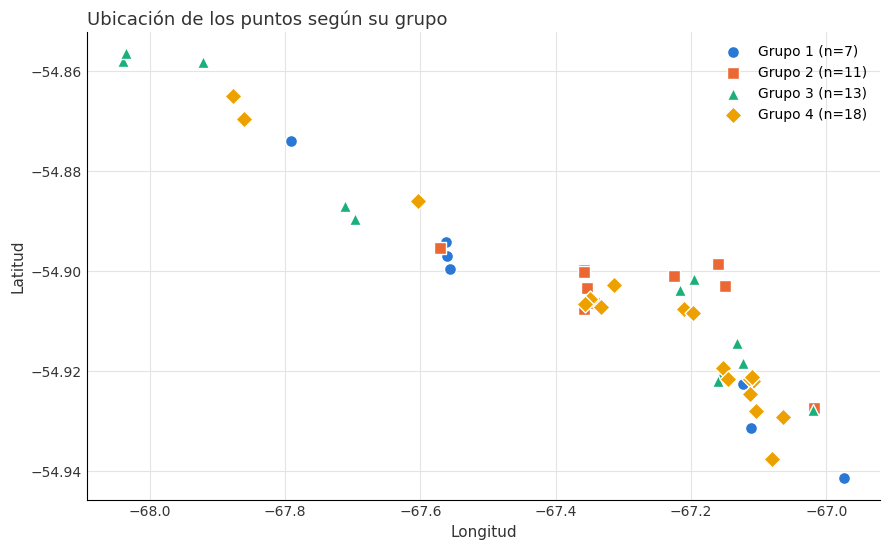

Puntos en el mapa: 49 de 55 (los 6 restantes, de enero y abril de 1996, no tienen coordenadas)


In [34]:
# Mapa (solo puntos con coordenadas)
m = d.dropna(subset=['latitud', 'longitud'])
fig, ax = plt.subplots(figsize=(9, 5.6))
for g in range(1, K + 1):
    s = m[m['grupo'] == g]
    ax.scatter(s['longitud'], s['latitud'], s=75, marker=MARCAS[g-1], color=COLORES[g-1], edgecolor='white', linewidth=1.0, label=f'Grupo {g} (n={len(s)})', zorder=3)
ax.set_xlabel('Longitud', fontsize=11, color=TINTA); ax.set_ylabel('Latitud', fontsize=11, color=TINTA)
ax.set_title('Ubicación de los puntos según su grupo', loc='left', fontsize=13, color=TINTA)
ax.grid(color=GRILLA, lw=0.8, zorder=0); ax.set_axisbelow(True)
for s_ in ('top', 'right'): ax.spines[s_].set_visible(False)
ax.tick_params(length=0, colors=TINTA); ax.legend(frameon=False, fontsize=10)
plt.tight_layout(); plt.show()
print(f'Puntos en el mapa: {len(m)} de {len(d)} (los {len(d)-len(m)} restantes, de enero y abril de 1996, no tienen coordenadas)')

*Figura 5. Ubicación de los 49 puntos con coordenadas, según su grupo. Cada marcador es un punto de muestreo; el color y la forma indican el grupo (los n de la leyenda cuentan solo los puntos con coordenadas). Los 6 puntos de enero y abril de 1996 no tienen coordenadas y no aparecen.*

**Interpretación.**

- **Los grupos están asociados a la campaña**, más de lo esperable por azar: la V de Cramér observada (0,51) supera el percentil 95 de la distribución por permutación (0,41; p aproximado = 0,0006). Por ejemplo, 5 de los 7 puntos del grupo 1 son de octubre de 1998; 8 de los 11 del grupo 2 son de julio y octubre de 1996; el grupo 4 se concentra en octubre de 1997 (9 de 22) y 4 de los 5 puntos de enero de 1996 también caen ahí.
- **Pero la campaña no determina el grupo.** Octubre de 1998 tiene puntos en los cuatro grupos, y octubre de 1996 en tres. Dentro de una misma campaña hay variedad de perfiles, en línea con el Punto 1.
- **No se ve una separación geográfica clara** en el mapa (Figura 5): puntos de distintos grupos aparecen mezclados en las mismas zonas. Esto es una observación visual, no se probó formalmente, y como cada punto pertenece a una sola campaña no se puede separar el efecto del lugar del efecto del tiempo.

### 2.8 Resumen del Punto 2

**Qué se hizo.** Se agruparon **55 de los 57 puntos** con k-means (k = 4) a partir de tres variables estandarizadas: porcentaje de hembras, talla mediana y porcentaje de hembras ovígeras.

**Resultado.**

| Grupo | Perfil | Puntos | Confiabilidad |
|---|---|---|---|
| 1 | Casi solo machos, talla grande | 7 | **Frágil**: depende de puntos con pocas hembras |
| 2 | Mayoría machos, pocas hembras con huevos | 11 | Robusto (se reproduce sin los puntos de pocas hembras) |
| 3 | Mayoría machos, hembras con huevos | 15 | Robusto |
| 4 | Mayoría hembras, con huevos | 22 | Robusto |

**Límites que condicionan el Punto 3 y el Punto 4.**

1. **Estructura débil**: silhouette de 0,36. Los puntos forman un continuo; los grupos son una segmentación descriptiva, no clases naturales.
2. **Los grupos se asocian a la campaña** (V de Cramér = 0,51; p ≈ 0,0006) pero no coinciden con ella. Como cada punto existe en una sola campaña, lugar y tiempo siguen confundidos.
3. **Se excluyeron 2 puntos sin hembras** (los más extremos en proporción de sexos), y el IAR no entra al agrupamiento por lo visto en 1.7. Con esta caracterización **no se puede decir dónde hay más centollón**, solo **qué tipo de captura hubo**.
4. **Solo centollón** (decisión D2 del Punto 1).

**Pasa al Punto 3.** Se describe la variabilidad temporal con los grupos ya formados: cómo cambia la composición de grupos entre campañas y qué parte de los cambios se puede atribuir al tiempo y no a distintos puntos muestreados cada vez.

## Punto 3 — Describir la variabilidad temporal

**Consigna.** *Describir la variabilidad temporal.*

**Entradas.** `puntos_tp3.csv` y `individuos_tp3.csv` (Punto 1) y `grupos_tp3.csv` (Punto 2).

### 3.0 Decisiones de diseño

| # | Decisión | Elegida | Alternativas descartadas | Justificación |
|---|---|---|---|---|
| T1 | **Unidad de tiempo** | La **campaña** (mes y año): hay 7 en total. | Agrupar por año o por estación. | Es la unidad con la que se registró el dato. Agrupar por estación mezclaría años distintos. |
| T2 | **Unidad estadística** | El **punto de muestreo** (57 puntos), no el individuo. | Comparar los 8.696 individuos. | Los individuos de un mismo punto no son independientes entre sí (se pescaron juntos). Tratarlos como independientes daría resultados "significativos" por tamaño de muestra y no por diferencias reales (pseudorreplicación). |
| T3 | **Comparaciones** | (a) **Octubre de 1996, 1997 y 1998** (mismo mes, tres años: la única comparación interanual limpia). (b) **Julio de 1996 frente a julio de 1997.** (c) Estacionalidad de 1996 solo **descriptiva**. | Comparar las 7 campañas a la vez. | Comparar campañas de meses distintos mezcla el efecto del año con el de la estación. Fijar el mes separa ambos efectos. Abril de 1996 tiene **un solo punto**: no admite ninguna prueba. |
| T4 | **Pruebas estadísticas** | Kruskal-Wallis (3 o más campañas) y Mann-Whitney (2 campañas), con corrección de Holm por familia de pruebas. Tamaño del efecto: ε² = H / (n − 1). | ANOVA, prueba t. | Hay entre 7 y 14 puntos por campaña y las variables son porcentajes acotados: no se justifica asumir normalidad. Holm controla el error cuando se hacen varias pruebas a la vez. |
| T5 | **% de ovígeras** | Solo puntos con **10 o más hembras evaluadas** en las pruebas (criterio E4 del Punto 2). | Usar todos los puntos. | Con menos hembras el porcentaje es muy inestable. |
| T6 | **Control por profundidad** | Se verifica si las campañas muestrearon profundidades distintas (3.2). | No controlar. | Si una campaña fue más profunda, la diferencia entre campañas podría deberse a la profundidad y no al tiempo. |

**Advertencia general.** Cada punto existe en **una sola campaña** (Punto 1): una diferencia entre campañas puede venir del tiempo o de que se muestrearon lugares distintos. Con estos datos **no se puede separar** ambas cosas; por eso se habla de "diferencias entre campañas" y no de "cambios de la población".

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.options.display.max_columns = 50
pd.options.display.width = 170
ORDEN_CAMPANAS = ['ene_96', 'abril_96', 'jul_96', 'oct_96', 'jul_97', 'oct_97', 'oct_98']
TINTA, GRILLA, AZUL = '#333333', '#E4E4E4', '#2B6CB0'
COLORES = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']   # paleta categórica (grupos del Punto 2)

puntos = pd.read_csv('puntos_tp3.csv')
ind = pd.read_csv('individuos_tp3.csv')
grupos = pd.read_csv('grupos_tp3.csv')
for t in (puntos, ind, grupos):
    t['fecha'] = pd.Categorical(t['fecha'], categories=ORDEN_CAMPANAS, ordered=True)
assert len(puntos) == 57 and len(ind) == 8696 and len(grupos) == 55

def holm(pvals):
    p = np.asarray(pvals, dtype=float); m = len(p)
    orden = np.argsort(p); aj = np.empty(m); previo = 0
    for rango, i in enumerate(orden):
        previo = max(previo, (m - rango) * p[i]); aj[i] = min(1, previo)
    return aj

def kruskal_tabla(df, variables, campanias, etiqueta_n=''):
    filas = []
    for v, nombre in variables.items():
        gs = [df.loc[df['fecha'] == c, v].dropna() for c in campanias]
        H, p = stats.kruskal(*gs)
        n = sum(len(g) for g in gs)
        fila = {'variable': nombre}
        for c, g in zip(campanias, gs):
            fila[f'{c}: mediana (n)'] = f'{g.median():.1f} ({len(g)})'
        fila.update({'H': H, 'p': p, 'ε²': H / (n - 1)})
        filas.append(fila)
    t = pd.DataFrame(filas).set_index('variable')
    t['p (Holm)'] = holm(t['p'].values)
    return t

### 3.1 Cobertura temporal: qué se muestreó y cuándo

**Acción.** Se resume cada campaña: cantidad de puntos, de individuos, de puntos con coordenadas y la profundidad.

In [36]:
cob = puntos.groupby('fecha', observed=True).agg(
    puntos=('localizacion', 'size'),
    individuos=('n_total', 'sum'),
    con_coordenadas=('latitud', lambda s: int(s.notna().sum())),
    profundidad_mediana=('profundidad', 'median'),
    prof_min=('profundidad', 'min'),
    prof_max=('profundidad', 'max'),
)
cob

,puntos,individuos,con_coordenadas,profundidad_mediana,prof_min,prof_max
fecha,,,,,,
ene_96,5,895,0,32.0,23.0,43.0
abril_96,1,164,0,30.0,30.0,30.0
jul_96,7,1631,7,22.0,19.0,30.0
oct_96,9,1261,9,30.0,21.0,49.0
jul_97,10,1343,10,24.5,18.0,57.0
oct_97,11,1791,11,30.0,23.0,40.0
oct_98,14,1611,14,33.0,19.0,45.0


**Interpretación.**

- Hay **7 campañas** que cubren solo **cuatro meses del año** (enero, abril, julio y octubre) a lo largo de tres años (1996 a 1998). No hay datos de febrero, marzo, mayo, junio, agosto, septiembre, noviembre ni diciembre.
- **Octubre es el único mes con tres años** (9, 11 y 14 puntos) y **julio el único con dos** (7 y 10 puntos). Por eso son las dos comparaciones interanuales posibles. Enero y abril aparecen una sola vez.
- **Abril de 1996 tiene un único punto**: no permite estimar variabilidad ni hacer comparaciones.
- Los 6 puntos de **enero y abril de 1996 no tienen coordenadas**: se pueden usar para describir en el tiempo, pero no para ubicar en el espacio.
- El período total es de solo **tres años**. Con estos datos se puede describir la variación entre esas campañas, pero **no una tendencia de largo plazo**.

### 3.2 Control: ¿las campañas muestrearon profundidades distintas?

**Acción.** Se compara la profundidad de los puntos entre campañas (T6), primero con todas las campañas y después solo con las tres de octubre.

In [37]:
con_n = [c for c in ORDEN_CAMPANAS if (puntos['fecha'] == c).sum() > 1]
gs = [puntos.loc[puntos['fecha'] == c, 'profundidad'].dropna() for c in con_n]
H, p_todas = stats.kruskal(*gs)
print(f'Todas las campañas con 2 o más puntos ({len(con_n)}): Kruskal-Wallis H = {H:.1f}, p = {p_todas:.3f}')
octs = ['oct_96', 'oct_97', 'oct_98']
gs = [puntos.loc[puntos['fecha'] == c, 'profundidad'].dropna() for c in octs]
H, p_oct = stats.kruskal(*gs)
print(f'Solo octubre 96, 97, 98:                  Kruskal-Wallis H = {H:.1f}, p = {p_oct:.3f}')
print('\nMediana de profundidad (m):', {c: float(puntos.loc[puntos['fecha'] == c, 'profundidad'].median()) for c in ORDEN_CAMPANAS})

Todas las campañas con 2 o más puntos (6): Kruskal-Wallis H = 12.5, p = 0.028
Solo octubre 96, 97, 98:                  Kruskal-Wallis H = 0.2, p = 0.910

Mediana de profundidad (m): {'ene_96': 32.0, 'abril_96': 30.0, 'jul_96': 22.0, 'oct_96': 30.0, 'jul_97': 24.5, 'oct_97': 30.0, 'oct_98': 33.0}


**Interpretación.** Entre todas las campañas la profundidad **sí difiere** (p = 0,028): julio de 1996 (mediana 22 m) y julio de 1997 (24,5 m) son más someras que el resto (30 a 33 m). Esto es una razón más para **no comparar campañas de meses distintos**, porque mezclaría estación y profundidad. En cambio, **entre los tres octubres no hay diferencia de profundidad** (medianas de 30, 30 y 33 m; p = 0,91). La comparación de octubres queda entonces mejor controlada por profundidad, aunque no por lugar.

### 3.3 Variabilidad interanual: octubre de 1996, 1997 y 1998

**Acción.** Con los puntos de cada octubre se comparan cinco indicadores: porcentaje de hembras, talla mediana de machos, talla mediana de hembras, porcentaje de hembras ovígeras y porcentaje de individuos maduros. Después, para los que dan diferencia, se hacen comparaciones de a pares (T4).

In [38]:
VARS_OCT = {'pct_hembras': '% hembras', 'largo_mediano_macho': 'talla mediana machos (mm)',
            'largo_mediano_hembra': 'talla mediana hembras (mm)', 'pct_ovigeras': '% ovígeras (≥10 hembras evaluadas)',
            'pct_maduros': '% maduros'}
p_oct_df = puntos[puntos['fecha'].isin(octs)].copy()
p_oct_df.loc[p_oct_df['n_hembras_evaluadas'] < 10, 'pct_ovigeras'] = np.nan     # T5
tabla_oct = kruskal_tabla(p_oct_df, VARS_OCT, octs)
tabla_oct.round({'H': 2, 'p': 3, 'ε²': 2, 'p (Holm)': 3})

,oct_96: mediana (n),oct_97: mediana (n),oct_98: mediana (n),H,p,ε²,p (Holm)
variable,,,,,,,
% hembras,23.1 (9),50.6 (11),15.9 (14),7.40,0.025,0.22,0.049
talla mediana machos (mm),77.3 (9),82.9 (11),87.0 (14),12.56,0.002,0.38,0.007
talla mediana hembras (mm),67.2 (8),69.7 (11),72.1 (13),12.58,0.002,0.41,0.007
% ovígeras (≥10 hembras evaluadas),60.8 (5),73.1 (11),76.9 (9),1.67,0.433,0.07,0.433
% maduros,96.2 (9),96.5 (11),100.0 (14),15.96,0.000,0.48,0.002


In [39]:
# Comparaciones de a pares (Mann-Whitney) para los indicadores con diferencia (p Holm < 0.05)
signif = tabla_oct.index[tabla_oct['p (Holm)'] < 0.05]
inv = {v: k for k, v in VARS_OCT.items()}
filas = []
for nombre in signif:
    v = inv[nombre]
    for a, b in [('oct_96', 'oct_97'), ('oct_97', 'oct_98'), ('oct_96', 'oct_98')]:
        x = p_oct_df.loc[p_oct_df['fecha'] == a, v].dropna(); y = p_oct_df.loc[p_oct_df['fecha'] == b, v].dropna()
        filas.append({'variable': nombre, 'comparación': f'{a} vs {b}', 'mediana A': x.median(), 'mediana B': y.median(),
                      'p': stats.mannwhitneyu(x, y).pvalue})
pares = pd.DataFrame(filas)
pares['p (Holm, dentro de cada variable)'] = pares.groupby('variable')['p'].transform(lambda s: holm(s.values))
pares.round({'mediana A': 1, 'mediana B': 1, 'p': 3, 'p (Holm, dentro de cada variable)': 3})

,variable,comparación,mediana A,mediana B,p,"p (Holm, dentro de cada variable)"
0,% hembras,oct_96 vs oct_97,23.1,50.6,0.149,0.298
1,% hembras,oct_97 vs oct_98,50.6,15.9,0.005,0.014
2,% hembras,oct_96 vs oct_98,23.1,15.9,0.659,0.659
3,talla mediana machos (mm),oct_96 vs oct_97,77.3,82.9,0.254,0.254
4,talla mediana machos (mm),oct_97 vs oct_98,82.9,87.0,0.005,0.010
5,talla mediana machos (mm),oct_96 vs oct_98,77.3,87.0,0.003,0.010
6,talla mediana hembras (mm),oct_96 vs oct_97,67.2,69.7,0.075,0.075
7,talla mediana hembras (mm),oct_97 vs oct_98,69.7,72.1,0.032,0.064
8,talla mediana hembras (mm),oct_96 vs oct_98,67.2,72.1,0.001,0.004
9,% maduros,oct_96 vs oct_97,96.2,96.5,1.000,1.000


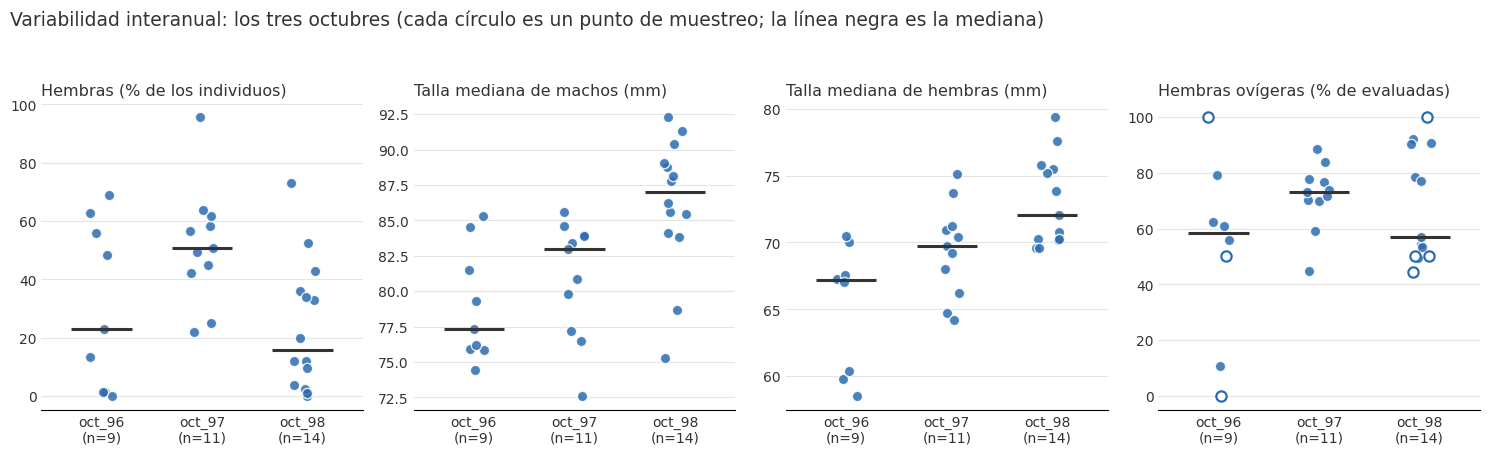

In [40]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4.6))
paneles = [('pct_hembras', 'Hembras (% de los individuos)'), ('largo_mediano_macho', 'Talla mediana de machos (mm)'),
           ('largo_mediano_hembra', 'Talla mediana de hembras (mm)'), ('pct_ovigeras', 'Hembras ovígeras (% de evaluadas)')]
rng = np.random.default_rng(0)
for ax, (v, tit) in zip(axs, paneles):
    for i, c in enumerate(octs):
        s = p_puntos = puntos[puntos['fecha'] == c]
        y = s[v]; x = i + rng.uniform(-0.12, 0.12, len(s))
        poco = (s['n_hembras_evaluadas'] < 10) if v == 'pct_ovigeras' else pd.Series(False, index=s.index)
        ax.scatter(x[~poco.values & y.notna().values], y[~poco & y.notna()], s=55, color=AZUL, alpha=0.85, edgecolor='white', linewidth=1.0, zorder=3)
        ax.scatter(x[poco.values & y.notna().values], y[poco & y.notna()], s=55, facecolor='white', edgecolor=AZUL, linewidth=1.6, zorder=3)
        ax.hlines(y.median(), i - 0.3, i + 0.3, color=TINTA, lw=2.2, zorder=4)
    ax.set_xticks(range(3)); ax.set_xticklabels([f'{c}\n(n={int((puntos.fecha == c).sum())})' for c in octs], fontsize=10)
    ax.set_title(tit, loc='left', fontsize=11.5, color=TINTA)
    ax.grid(axis='y', color=GRILLA, lw=0.8, zorder=0); ax.set_axisbelow(True)
    for s_ in ('top', 'right', 'left'): ax.spines[s_].set_visible(False)
    ax.tick_params(length=0, colors=TINTA); ax.set_xlim(-0.6, 2.6)
fig.suptitle('Variabilidad interanual: los tres octubres (cada círculo es un punto de muestreo; la línea negra es la mediana)', x=0.01, ha='left', fontsize=13.5, color=TINTA)
fig.tight_layout(rect=(0, 0, 1, 0.93)); plt.show()

*Figura 6. Indicadores por punto de muestreo en los tres octubres con datos (1996, 1997 y 1998). Cada círculo es un punto; la línea negra es la mediana de la campaña; n es la cantidad de puntos. En el último panel, los círculos huecos son puntos con menos de 10 hembras evaluadas (no entran en las pruebas). De izquierda a derecha: porcentaje de hembras, talla mediana de machos, talla mediana de hembras y porcentaje de hembras ovígeras.*

**Interpretación.**

- **La talla de machos y de hembras aumenta de un octubre a otro.** La mediana de los puntos pasa de 77,3 a 82,9 y a 87,0 mm en machos, y de 67,2 a 69,7 y a 72,1 mm en hembras. Las diferencias son claras (p con corrección de Holm = 0,007 en ambos sexos; ε² = 0,38 y 0,41, efectos grandes). Las diferencias de a pares muestran que el salto principal es el de octubre de 1998: en machos difiere de los dos octubres anteriores, y en hembras difiere de octubre de 1996.
- **Casi desaparecen los ejemplares inmaduros.** El porcentaje de maduros por punto pasa de una mediana de 96,2% y 96,5% a 100% en octubre de 1998 (p Holm = 0,002; en esa campaña, el 99,4% de los individuos agregados son maduros). Es coherente con el aumento de talla.
- **La proporción de hembras no sigue una tendencia**: 23,1%, 50,6% y 15,9% de mediana. Octubre de 1997 se distingue de octubre de 1998 (p Holm = 0,014). La diferencia global es la más justa de las cinco (p Holm = 0,049), así que se la toma con cautela.
- **El porcentaje de ovígeras no muestra diferencias detectables** (60,8%, 73,1% y 76,9%; p Holm = 0,43). Pero octubre de 1996 solo tiene 5 puntos con 10 o más hembras evaluadas, por lo que la prueba tiene poca potencia: *no detectar diferencia no equivale a que no la haya*.

**Qué no se puede concluir.** El aumento de talla **no indica que la población esté mejor**. Los datos no permiten saber su causa. Podría deberse a que se muestrearon sitios distintos cada año, a cambios en el arte de pesca o en la selectividad, o a que ingresaron menos ejemplares jóvenes a la captura. Tampoco contradice la preocupación del enunciado sobre la sobrepesca: son tres años y el problema que describe la nota abarca unos 20 años. Lo único que se puede afirmar es que **en estas tres campañas de octubre, lo capturado fue cada vez más grande y más maduro**.

### 3.4 Julio de 1996 frente a julio de 1997

**Acción.** Se compara el mismo mes en dos años (T3b) con Mann-Whitney sobre los puntos.

In [41]:
jul = puntos[puntos['fecha'].isin(['jul_96', 'jul_97'])].copy()
jul.loc[jul['n_hembras_evaluadas'] < 10, 'pct_ovigeras'] = np.nan
VARS_JUL = {'pct_hembras': '% hembras', 'largo_mediano': 'talla mediana (mm)', 'pct_ovigeras': '% ovígeras (≥10 hembras evaluadas)'}
filas = []
for v, nombre in VARS_JUL.items():
    a = jul.loc[jul['fecha'] == 'jul_96', v].dropna(); b = jul.loc[jul['fecha'] == 'jul_97', v].dropna()
    U, p = stats.mannwhitneyu(a, b)
    filas.append({'variable': nombre, 'jul_96: mediana (n)': f'{a.median():.1f} ({len(a)})', 'jul_97: mediana (n)': f'{b.median():.1f} ({len(b)})', 'p': p})
tj = pd.DataFrame(filas).set_index('variable'); tj['p (Holm)'] = holm(tj['p'].values)
tj.round({'p': 3, 'p (Holm)': 3})

,jul_96: mediana (n),jul_97: mediana (n),p,p (Holm)
variable,,,,
% hembras,16.9 (7),37.6 (10),0.315,0.315
talla mediana (mm),72.9 (7),76.6 (10),0.130,0.260
% ovígeras (≥10 hembras evaluadas),31.1 (7),72.7 (9),0.008,0.024


**Interpretación.** Solo cambia de forma clara el **porcentaje de hembras ovígeras**: mediana de 31,1% en julio de 1996 y de 72,7% en julio de 1997 (p Holm = 0,024). El porcentaje de hembras y la talla mediana no difieren de manera detectable (p Holm = 0,32 y 0,26), aunque con 7 y 10 puntos la prueba tiene poca potencia. Como se trata **del mismo mes**, la diferencia en ovígeras **no se explica por la época del año**. Las posibilidades son una diferencia real entre años, otros lugares muestreados o diferencias de registro (ver 3.6); con los datos no se puede decidir entre ellas.

### 3.5 Estacionalidad dentro de 1996 (descriptivo)

**Acción.** Se muestra la secuencia enero, abril, julio y octubre de 1996 (T3c). **No se hacen pruebas**: abril tiene un solo punto y enero cinco.

In [42]:
est = puntos[puntos['fecha'].isin(['ene_96', 'abril_96', 'jul_96', 'oct_96'])].copy()
est.loc[est['n_hembras_evaluadas'] < 10, 'pct_ovigeras_firme'] = np.nan
est['pct_ovigeras_firme'] = est['pct_ovigeras'].where(est['n_hembras_evaluadas'] >= 10)
est.groupby('fecha', observed=True).agg(puntos=('localizacion', 'size'), pct_hembras_mediana=('pct_hembras', 'median'),
    pct_ovigeras_mediana=('pct_ovigeras_firme', 'median'), puntos_con_ovigeras_firmes=('pct_ovigeras_firme', 'count')).round(1)

,puntos,pct_hembras_mediana,pct_ovigeras_mediana,puntos_con_ovigeras_firmes
fecha,,,,
ene_96,5,67.6,81.3,5
abril_96,1,22.0,90.9,1
jul_96,7,16.9,31.1,7
oct_96,9,23.1,60.8,5


**Interpretación.** El porcentaje de hembras en los puntos baja de enero (mediana 67,6%) a julio (16,9%) y vuelve a subir un poco en octubre (23,1%). El de ovígeras baja de enero (81,3%) a julio (31,1%) y recupera en octubre (60,8%, sobre solo 5 puntos con datos firmes). Esa secuencia parece estacional, pero **no se repite en 1997 y 1998**, cuando julio (72,7%) y octubre (73,1% y 76,9%) tienen porcentajes altos de ovígeras (3.3 y 3.4). Por eso **no se puede atribuir a la época del año**, y no se la usa para proponer un calendario de pesca. Hubo hembras con huevos en los cuatro meses muestreados. La nota del enunciado afirma que las hembras llevan los huevos de enero a octubre, pero lo dice de la **centolla**; aquí se analiza el **centollón**, de modo que es un punto de comparación y no una confirmación.

### 3.6 Calidad del dato reproductivo: ¿se registró igual en todas las campañas?

**Acción.** Antes de interpretar el porcentaje de ovígeras, se mira cómo se distribuyen los **códigos de huevos** (`huevos`) de las hembras evaluadas en cada campaña. Si el código se usó distinto según la campaña, parte de la variación observada sería de registro y no biológica.

In [43]:
h = ind[ind['hembra_evaluada']].copy()
def categoria(c):
    return ('0: sin huevos' if c == 0 else '1' if c == 1 else '3' if c == 3 else '30' if c == 30 else 'otros (2, 4, 5, 6, 7, 40)')
h['cat'] = h['huevos_cod'].map(categoria)
ORD_CAT = ['0: sin huevos', '1', '3', '30', 'otros (2, 4, 5, 6, 7, 40)']
prop = (pd.crosstab(h['fecha'], h['cat'], normalize='index')[ORD_CAT] * 100).round(1)
n_h = h.groupby('fecha', observed=True).size().rename('hembras evaluadas')
pd.concat([prop, n_h], axis=1)

,0: sin huevos,1,3,30,"otros (2, 4, 5, 6, 7, 40)",hembras evaluadas
fecha,,,,,,
ene_96,10.8,68.8,2.2,0.7,17.5,554
abril_96,9.1,84.8,6.1,0.0,0.0,33
jul_96,61.4,35.6,1.1,0.3,1.7,360
oct_96,43.4,21.6,8.4,8.6,18.0,394
jul_97,11.9,32.4,37.1,3.1,15.5,587
oct_97,16.7,29.1,1.4,37.2,15.6,945
oct_98,13.4,46.6,1.6,15.1,23.3,425


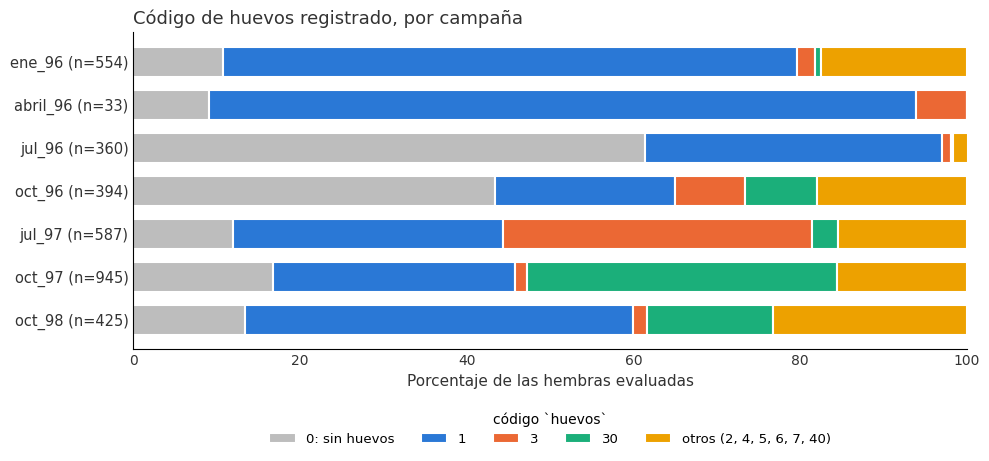

In [44]:
fig, ax = plt.subplots(figsize=(10, 4.8))
izq = np.zeros(len(prop))
cols = ['#BDBDBD', COLORES[0], COLORES[1], COLORES[2], COLORES[3]]
for cat, col in zip(ORD_CAT, cols):
    ax.barh(range(len(prop)), prop[cat].values, left=izq, color=col, edgecolor='white', linewidth=1.5, label=cat, height=0.7)
    izq += prop[cat].values
ax.set_yticks(range(len(prop))); ax.set_yticklabels([f'{c} (n={n})' for c, n in zip(prop.index, n_h)], fontsize=10.5)
ax.invert_yaxis(); ax.set_xlim(0, 100); ax.set_xlabel('Porcentaje de las hembras evaluadas', fontsize=11, color=TINTA)
ax.set_title('Código de huevos registrado, por campaña', loc='left', fontsize=13, color=TINTA)
ax.legend(title='código `huevos`', frameon=False, fontsize=9.5, ncol=5, loc='upper center', bbox_to_anchor=(0.5, -0.16))
for s_ in ('top', 'right'): ax.spines[s_].set_visible(False)
ax.tick_params(length=0, colors=TINTA); plt.tight_layout(); plt.show()

*Figura 7. Distribución del código de huevos (`huevos`) entre las hembras evaluadas de cada campaña. Cada barra suma 100%; n es la cantidad de hembras evaluadas. Los códigos 1, 3 y 30 se muestran por separado por ser los más usados; el resto de los códigos (2, 4, 5, 6, 7 y 40) se agrupa en "otros".*

**Interpretación.** El uso de los códigos **cambia mucho de una campaña a otra**:

- En julio de 1996, el 61,4% de las hembras figura **sin huevos** (código 0); en julio de 1997, solo el 11,9%.
- El código **3** concentra el 37,1% de las hembras de julio de 1997 y no supera el 8,4% en ninguna otra campaña.
- El código **30** concentra el 37,2% en octubre de 1997, 15,1% en octubre de 1998 y 8,6% en octubre de 1996, y casi no aparece en el resto (0 a 3,1%).

Es un patrón compatible con que cada campaña haya usado convenciones de registro distintas para las etapas del desarrollo de los huevos, pero **los datos no permiten confirmarlo**: es una hipótesis. Tres consecuencias para el análisis:

1. El **porcentaje de ovígeras** suma todos los códigos con huevos, así que **no depende de qué subetapa se haya anotado**. Se mantiene como indicador.
2. La **composición por etapa de desarrollo** (por ejemplo, cuántas hembras tienen huevos recién puestos frente a huevos avanzados) **no es comparable entre campañas**. No se usa para sacar conclusiones.
3. El 61,4% de hembras sin huevos de julio de 1996 puede ser real o un artefacto de registro. Se lo deja como **pregunta para la mentora**, porque determina cuánto peso darle a la diferencia de ovígeras entre julio de 1996 y julio de 1997.

### 3.7 Los grupos del Punto 2 a lo largo del tiempo

**Acción.** Se cuenta la proporción de puntos de cada grupo en cada campaña (55 puntos agrupados).

In [45]:
gt = puntos.merge(grupos, on=['localizacion', 'fecha'], how='inner')
assert len(gt) == 55
tab_g = pd.crosstab(gt['fecha'], gt['grupo'])
tab_g['total'] = tab_g.sum(axis=1)
prop_g = tab_g.drop(columns='total').div(tab_g['total'], axis=0) * 100
tab_g

grupo,1,2,3,4,total
fecha,,,,,
ene_96,0,0,1,4,5
abril_96,0,0,1,0,1
jul_96,1,5,0,1,7
oct_96,0,3,2,3,8
jul_97,1,1,5,3,10
oct_97,0,1,1,9,11
oct_98,5,1,5,2,13


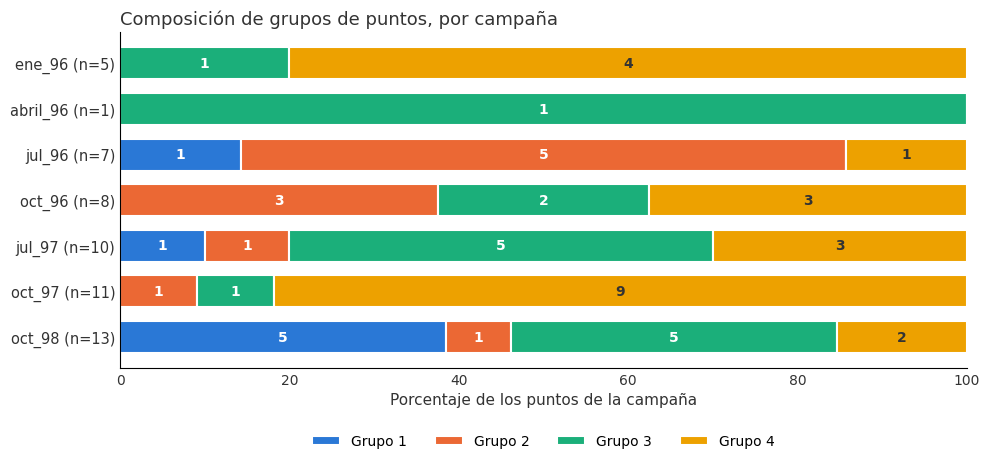

In [46]:
fig, ax = plt.subplots(figsize=(10, 4.8))
izq = np.zeros(len(prop_g))
for g, col in zip(prop_g.columns, COLORES):
    ax.barh(range(len(prop_g)), prop_g[g].values, left=izq, color=col, edgecolor='white', linewidth=1.5, label=f'Grupo {g}', height=0.7)
    for i, (v, l) in enumerate(zip(prop_g[g].values, izq)):
        n = tab_g.loc[prop_g.index[i], g]
        if n > 0: ax.text(l + v / 2, i, str(int(n)), ha='center', va='center', fontsize=10, color=(TINTA if g == 4 else 'white'), fontweight='bold')
    izq += prop_g[g].values
ax.set_yticks(range(len(prop_g))); ax.set_yticklabels([f'{c} (n={n})' for c, n in zip(prop_g.index, tab_g['total'])], fontsize=10.5)
ax.invert_yaxis(); ax.set_xlim(0, 100); ax.set_xlabel('Porcentaje de los puntos de la campaña', fontsize=11, color=TINTA)
ax.set_title('Composición de grupos de puntos, por campaña', loc='left', fontsize=13, color=TINTA)
ax.legend(frameon=False, fontsize=10, ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.16))
for s_ in ('top', 'right'): ax.spines[s_].set_visible(False)
ax.tick_params(length=0, colors=TINTA); plt.tight_layout(); plt.show()

*Figura 8. Composición de grupos de puntos (Punto 2) en cada campaña. Cada barra suma 100% de los puntos agrupados de la campaña; el número dentro de cada segmento es la cantidad de puntos; n es el total. Octubre de 1996 y octubre de 1998 tienen un punto menos que en el Punto 1 porque se excluyeron los puntos sin hembras.*

**Interpretación.** La composición de grupos cambia entre campañas, en línea con la asociación encontrada en el Punto 2:

- El **grupo 4** (mayoría de hembras con huevos) domina enero de 1996 (4 de 5 puntos) y octubre de 1997 (9 de 11).
- El **grupo 2** (mayoría de machos, pocas hembras con huevos) domina julio de 1996 (5 de 7).
- El **grupo 1** (machos grandes) aparece sobre todo en octubre de 1998 (5 de 13), y el **grupo 3** en julio de 1997 (5 de 10) y octubre de 1998 (5 de 13).
- **Ninguna campaña de 7 o más puntos tiene un solo grupo**: todas incluyen al menos tres de los cuatro.

Es decir que el tiempo **modifica la mezcla de perfiles, pero no la determina**. Esto concuerda con lo visto en la comparación de octubres (3.3): en 1998 aparecen más puntos de machos grandes, y en 1997 más puntos con muchas hembras.

### 3.8 Resumen del Punto 3

**Qué varía entre campañas (y con qué respaldo).**

| Aspecto | Qué se observa | Respaldo |
|---|---|---|
| **Talla** | Aumenta en octubre de 1996 a 1998 en ambos sexos; casi no hay inmaduros en 1998 | **Firme** dentro de la comparación (p Holm = 0,007 y 0,002; efectos grandes) |
| **Proporción de hembras** | Oscila entre octubres (23%, 51%, 16%), sin tendencia | Moderado (p Holm = 0,049) |
| **Hembras ovígeras** | Julio de 1996 (31%) distinto de julio de 1997 (73%); sin patrón estacional | Moderado, y **condicionado por diferencias de registro** (3.6) |
| **Mezcla de grupos (Punto 2)** | Cambia entre campañas pero ninguna es de un solo grupo | Descriptivo |
| **Abundancia** | No se describe | El IAR no es interpretable (1.7) |

**Qué no se puede afirmar.**

1. **Una tendencia de largo plazo o un "decaimiento"**: son 3 años, 7 campañas, solo 4 meses del año.
2. **Un calendario estacional**: la secuencia de 1996 no se repite en 1997 y 1998, y abril tiene un solo punto.
3. **Que las diferencias se deban al tiempo**: cada punto existe en una sola campaña, así que lugar y tiempo están confundidos.
4. **Comparar etapas de desarrollo de los huevos** entre campañas: el registro es heterogéneo.

**Preguntas abiertas para la mentora (se suman a las del Punto 1).**

- ¿Se usó la misma convención de códigos de huevos en todas las campañas? En particular, ¿qué significan las grandes diferencias en el uso de los códigos 0, 3 y 30?
- ¿Se usaron las mismas artes de pesca y las mismas trampas en todas las campañas? Condiciona la lectura del aumento de talla.
- ¿Los lugares de octubre de 1996, 1997 y 1998 se eligieron con el mismo criterio?

**Pasa al Punto 4.** La recomendación debe apoyarse en lo que sí resultó firme y declarar con claridad lo que no se pudo concluir.

## Punto 4 — Recomendación para el gobierno local

**Consigna.** *Redactar una recomendación para el gobierno local que tenga por objetivo la subsistencia del recurso pesquero a lo largo del tiempo.*

### 4.0 Cómo se construye la recomendación

| # | Decisión | Elegida | Justificación |
|---|---|---|---|
| R0a | **Cada recomendación debe apoyarse en un resultado de los Puntos 1 a 3** | Cada una indica la evidencia, el grado de respaldo y lo que falta. | Una recomendación sin evidencia trazable no se puede defender ni corregir. |
| R0b | **Se priorizan medidas que se sostienen con lo que se vio y que no dependen de lo que los datos no permiten afirmar** | Se evitan medidas que requieran saber *cuándo* hay más hembras con huevos o *cuánto* centollón hay. | Los Puntos 1 y 3 mostraron que el índice de abundancia no es interpretable y que la secuencia estacional no se repite entre años. |
| R0c | **Alcance** | Solo **centollón**. | Es la especie analizada (D2 del Punto 1). La centolla requiere un análisis propio. |
| R0d | **Se declara explícitamente lo que no se puede concluir** | Sección propia (4.4). | Es parte de una recomendación honesta: quien decide necesita saber qué es sólido y qué no. |

La recomendación incluye también un **plan para generar mejores datos**, porque las principales limitaciones del análisis vienen de cómo se registraron los muestreos.

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.options.display.max_columns = 50
pd.options.display.width = 170
ORDEN_CAMPANAS = ['ene_96', 'abril_96', 'jul_96', 'oct_96', 'jul_97', 'oct_97', 'oct_98']
TINTA, GRILLA, AZUL, GRIS = '#333333', '#E4E4E4', '#2B6CB0', '#9A9A9A'

puntos = pd.read_csv('puntos_tp3.csv')
grupos = pd.read_csv('grupos_tp3.csv')
puntos['fecha'] = pd.Categorical(puntos['fecha'], categories=ORDEN_CAMPANAS, ordered=True)
assert len(puntos) == 57

### 4.1 Evidencia: cuánto de lo registrado son hembras con huevos

**Acción.** Por campaña se calcula qué porcentaje de los individuos registrados son **hembras ovígeras** y qué porcentaje de las hembras evaluadas llevaban huevos. Es la magnitud de lo que se devolvería al agua si se protegiera a esas hembras.

**Justificación.** Para proteger la reproducción hay que saber qué parte de lo que se saca son hembras con huevos. Se usan los individuos registrados en los puntos (no la abundancia en el mar, que con estos datos no se puede estimar).

In [48]:
camp = puntos.groupby('fecha', observed=True)[['n_total', 'n_hembras', 'n_hembras_evaluadas', 'n_ovigeras', 'n_vulnerables']].sum()
ev = pd.DataFrame({
    'individuos_registrados': camp['n_total'],
    'hembras_evaluadas': camp['n_hembras_evaluadas'],
    '% de lo registrado: hembras ovígeras': 100 * camp['n_ovigeras'] / camp['n_total'],
    '% de lo registrado: hembras ovígeras o con cápsulas vacías': 100 * camp['n_vulnerables'] / camp['n_total'],
    '% de las hembras evaluadas que son ovígeras': 100 * camp['n_ovigeras'] / camp['n_hembras_evaluadas'],
}).round(1)
tot = camp.sum()
print(f"TOTAL ({int(tot['n_total']):,} individuos): hembras ovígeras = {100*tot['n_ovigeras']/tot['n_total']:.1f}% de lo registrado; "
      f"ovígeras o con cápsulas vacías = {100*tot['n_vulnerables']/tot['n_total']:.1f}%; "
      f"ovígeras = {100*tot['n_ovigeras']/tot['n_hembras_evaluadas']:.1f}% de las hembras evaluadas")
ev

TOTAL (8,696 individuos): hembras ovígeras = 26.4% de lo registrado; ovígeras o con cápsulas vacías = 29.4%; ovígeras = 69.7% de las hembras evaluadas


,individuos_registrados,hembras_evaluadas,% de lo registrado: hembras ovígeras,% de lo registrado: hembras ovígeras o con cápsulas vacías,% de las hembras evaluadas que son ovígeras
fecha,,,,,
ene_96,895,554,48.5,55.2,78.3
abril_96,164,33,18.3,18.3,90.9
jul_96,1631,360,8.5,8.5,38.3
oct_96,1261,394,16.3,17.7,52.3
jul_97,1343,587,33.8,38.5,77.3
oct_97,1791,945,40.0,43.9,75.8
oct_98,1611,425,19.9,22.8,75.3


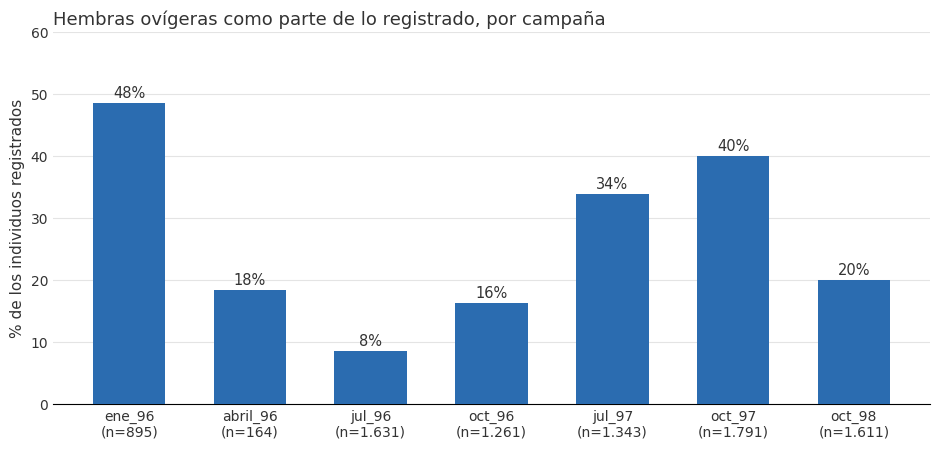

In [49]:
fig, ax = plt.subplots(figsize=(9.5, 4.6))
v = ev['% de lo registrado: hembras ovígeras']
ax.bar(range(len(v)), v.values, color=AZUL, width=0.6, zorder=3)
for i, (val, n) in enumerate(zip(v.values, ev['individuos_registrados'])):
    ax.text(i, val + 1, f'{val:.0f}%', ha='center', fontsize=10.5, color=TINTA)
ax.set_xticks(range(len(v))); ax.set_xticklabels([f'{c}\n(n={int(n):,})'.replace(',', '.') for c, n in zip(v.index, ev['individuos_registrados'])], fontsize=10)
ax.set_ylabel('% de los individuos registrados', fontsize=11, color=TINTA); ax.set_ylim(0, 60)
ax.set_title('Hembras ovígeras como parte de lo registrado, por campaña', loc='left', fontsize=13, color=TINTA)
ax.grid(axis='y', color=GRILLA, lw=0.8, zorder=0); ax.set_axisbelow(True)
for s_ in ('top', 'right', 'left'): ax.spines[s_].set_visible(False)
ax.tick_params(length=0, colors=TINTA); plt.tight_layout(); plt.show()

*Figura 9. Porcentaje de los individuos registrados que son hembras ovígeras, por campaña. Cada barra es una campaña; n es la cantidad de individuos registrados. Los porcentajes se calculan sobre el total de individuos de los puntos de la campaña, no sobre las hembras.*

**Interpretación.**

- En total, el **26,4% de los individuos registrados (2.298 de 8.696) son hembras ovígeras**; sumando las hembras con cápsulas vacías, el 29,4%. Entre las hembras con dato de huevos, el 69,7% llevaba huevos.
- **En las siete campañas hubo hembras con huevos**: entre el 38% y el 91% de las hembras evaluadas. En cinco de las siete campañas (enero y abril de 1996, julio de 1997, octubre de 1997 y octubre de 1998), el porcentaje fue de 75% a 91%. Julio y octubre de 1996 son las excepciones (38,3% y 52,3%), con el reparo sobre el registro visto en 3.6.
- La parte de lo registrado que corresponde a hembras ovígeras **varía mucho según la campaña**: 8,5% en julio de 1996, pero 40,0% en octubre de 1997 y 48,5% en enero de 1996. Donde las hembras son abundantes, una gran parte de lo registrado es la fracción reproductiva.

**Qué significa para el manejo.** Si se devolvieran al agua las hembras con huevos, en estos registros se dejaría de retener en promedio **algo más de una cuarta parte de los individuos**, y entre 4 y 5 de cada 10 en las campañas con más hembras. **Reparo:** los porcentajes se refieren a lo *registrado* en los puntos; no se sabe si es toda la captura o un submuestreo (pregunta abierta de 1.7).

### 4.2 Dónde: sitios candidatos a protección

**Acción.** Se aplica una regla simple y explícita para identificar puntos donde se concentra la fracción reproductiva: **al menos 80% de las hembras evaluadas con huevos, 10 o más hembras evaluadas y mayoría de hembras en la captura (más de 50%)**.

**Decisión y justificación.** Se usan **porcentajes y no cantidades**, porque el número de individuos por punto no depende del esfuerzo (1.7) y las cantidades quedarían determinadas por cuántos se midieron. El umbral de 80% es una elección del grupo, sin base externa: se muestra el cuadro completo para que se pueda cambiar. **Los sitios son candidatos, no una lista cerrada:** cada uno fue muestreado en una sola campaña, así que con estos datos no se sabe si el resultado es del lugar o de la fecha.

In [50]:
m = puntos.merge(grupos, on=['localizacion', 'fecha'], how='left')
cand = m[(m['pct_ovigeras'] >= 80) & (m['n_hembras_evaluadas'] >= 10) & (m['pct_hembras'] > 50)].copy()
cand = cand.sort_values('pct_ovigeras', ascending=False)
tabla_cand = cand[['localizacion', 'fecha', 'latitud', 'longitud', 'profundidad', 'n_hembras_evaluadas', 'pct_hembras', 'pct_ovigeras', 'grupo']].round({'latitud': 4, 'longitud': 4, 'profundidad': 0, 'pct_hembras': 1, 'pct_ovigeras': 1, 'grupo': 0})
print(f'Sitios candidatos: {len(cand)} de {len(puntos)} puntos | con coordenadas: {int(cand.latitud.notna().sum())}')
print('Campañas de los candidatos:', cand['fecha'].value_counts().reindex(ORDEN_CAMPANAS).dropna().astype(int).to_dict())
tabla_cand['grupo'] = tabla_cand['grupo'].astype('Int64')
tabla_cand.reset_index(drop=True)

Sitios candidatos: 7 de 57 puntos | con coordenadas: 5
Campañas de los candidatos: {'ene_96': 2, 'jul_97': 2, 'oct_97': 2, 'oct_98': 1}


,localizacion,fecha,latitud,longitud,profundidad,n_hembras_evaluadas,pct_hembras,pct_ovigeras,grupo
0,wp 154,jul_97,-54.8650,-67.8773,21.0,136,82.0,93.4,4
1,wp 236,oct_98,-54.8861,-67.6030,28.0,116,73.2,90.5,4
2,wp 172,oct_97,-54.9293,-67.0642,40.0,199,95.7,88.4,4
3,S islote Belgrano/punta navarro,ene_96,NaN,NaN,27.0,91,76.9,85.7,4
4,al S de baliza de E. Remolino,jul_97,-54.8696,-67.8606,18.0,117,83.6,84.6,4
5,wp 165,oct_97,-54.9084,-67.1968,32.0,93,61.6,83.9,4
6,SW Ilote Belgrano,ene_96,NaN,NaN,40.0,109,67.6,81.7,4


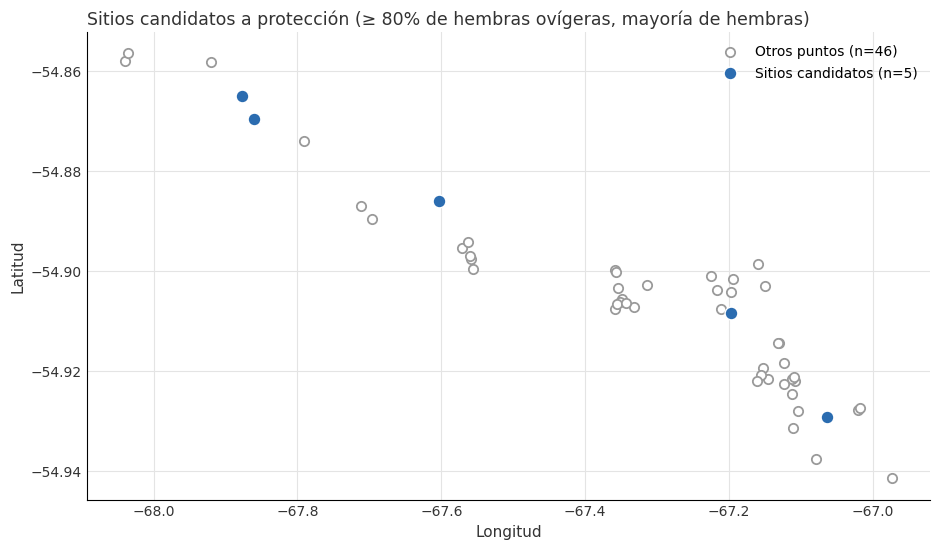

In [51]:
mm = puntos.dropna(subset=['latitud', 'longitud'])
fig, ax = plt.subplots(figsize=(9.5, 5.6))
ax.scatter(mm['longitud'], mm['latitud'], s=45, facecolor='white', edgecolor=GRIS, linewidth=1.3, label=f'Otros puntos (n={len(mm) - int(cand.latitud.notna().sum())})', zorder=2)
c = cand.dropna(subset=['latitud', 'longitud'])
ax.scatter(c['longitud'], c['latitud'], s=85, color=AZUL, edgecolor='white', linewidth=1.0, label=f'Sitios candidatos (n={len(c)})', zorder=3)
ax.set_xlabel('Longitud', fontsize=11, color=TINTA); ax.set_ylabel('Latitud', fontsize=11, color=TINTA)
ax.set_title('Sitios candidatos a protección (≥ 80% de hembras ovígeras, mayoría de hembras)', loc='left', fontsize=12.5, color=TINTA)
ax.grid(color=GRILLA, lw=0.8, zorder=0); ax.set_axisbelow(True)
for s_ in ('top', 'right'): ax.spines[s_].set_visible(False)
ax.tick_params(length=0, colors=TINTA); ax.legend(frameon=False, fontsize=10); plt.tight_layout(); plt.show()

*Figura 10. Ubicación de los 51 puntos con coordenadas. Los círculos azules son los 5 sitios candidatos con coordenadas (de 7 en total; los otros 2, de enero de 1996, no tienen coordenadas); los círculos huecos son el resto. Criterio de candidato: al menos 80% de hembras ovígeras entre las evaluadas, 10 o más hembras evaluadas y más de 50% de hembras en el punto.*

**Interpretación.**

- **7 de los 57 puntos** cumplen la regla, y **5 tienen coordenadas**. Los 7 pertenecen al grupo 4 del Punto 2 (mayoría de hembras con huevos), lo que da consistencia entre ambos criterios, aunque la regla se definió de manera independiente.
- Los candidatos provienen de **cuatro campañas distintas** (enero de 1996: 2; julio de 1997: 2; octubre de 1997: 2; octubre de 1998: 1) y tienen profundidades de 18 a 40 m.
- **No forman una zona única**: los 5 con coordenadas están repartidos en tres sectores del canal (longitudes cercanas a −67,88 y −67,86; −67,60; y −67,20 y −67,06).
- Cada sitio fue muestreado **una sola vez**: no sabemos si la alta proporción de hembras con huevos es una propiedad del lugar o del momento. Por eso se los propone como **sitios a re-muestrear con prioridad** y no como zonas de veda definitivas.

### 4.3 Recomendación al gobierno local

**A quién va dirigida.** A la autoridad de aplicación de estos recursos pesqueros y al gobierno local (municipalidad de Ushuaia).

**Base.** 8.696 centollones registrados en 57 puntos de muestreo del Canal Beagle, en siete campañas entre enero de 1996 y octubre de 1998. Los datos describen *qué se pescó* en cada punto; **no permiten estimar cuánto centollón hay** ni **si la población disminuyó** (ver 4.4).

#### Respuesta corta a las preguntas del proyecto

- **¿Dónde se recomienda no pescar?** Con prioridad en los **7 sitios candidatos** de 4.2 (5 con coordenadas), hasta volver a muestrearlos. No hay base para cerrar una zona definitiva.
- **¿Cuándo se recomienda no pescar?** Estos datos **no permiten fijar una época**: hubo hembras con huevos en todos los meses muestreados y el patrón no se repitió entre años. Se recomienda, en cambio, una protección **durante todo el año** sobre las hembras con huevos (Recomendación 1).

#### Recomendaciones

**1. Proteger a las hembras ovígeras: devolverlas vivas al agua (medida principal).**
- *Evidencia:* son el 26,4% de lo registrado y entre el 38% y el 91% de las hembras evaluadas en todas las campañas; llegan a 4 o 5 de cada 10 individuos en las campañas con más hembras (4.1).
- *Por qué esta medida y no un calendario:* no depende de saber cuándo hay más hembras con huevos, algo que los datos no permiten determinar (3.5).
- *Respaldo:* **alto para la magnitud** (qué parte de lo registrado se protegería); **desconocido para el efecto sobre la población**, porque los datos no informan la supervivencia de las hembras devueltas.
- *Qué falta:* definir cómo se verifica en la práctica y medir esa supervivencia.

**2. Re-muestrear con prioridad los 7 sitios candidatos, con protocolo estándar, y evaluar un resguardo si el patrón se repite.**
- *Evidencia:* 7 puntos con al menos 80% de hembras ovígeras y mayoría de hembras; todos del grupo 4 (4.2, 2.5).
- *Respaldo:* **medio-bajo**: cada sitio se muestreó una sola vez, por lo que no se puede separar lugar de fecha.
- *Qué falta:* repeticiones del muestreo en los mismos sitios y en distintas épocas.

**3. No establecer, por ahora, un calendario de veda a partir de estos datos.**
- *Evidencia:* hubo hembras con huevos en enero, abril, julio y octubre; la secuencia de 1996 (menos huevos en julio) no se repitió en 1997 y 1998; y los códigos de huevos se usaron de manera distinta según la campaña (3.4 a 3.6).
- *Respaldo:* **medio**. Es una recomendación de cautela: un calendario basado en estos datos podría proteger la época equivocada y dejar sin cubrir meses que no se muestrearon (solo hay datos de 4 meses).

**4. Seguir la talla y el porcentaje de ejemplares inmaduros como indicadores de alerta.**
- *Evidencia:* entre los tres octubres la talla aumentó en machos y hembras y en octubre de 1998 el 99,4% de lo registrado era maduro (3.3).
- *Lectura prudente:* un aumento de talla **no implica una población sana**; podría reflejar que ingresan pocos ejemplares jóvenes a la captura, o simplemente otros sitios y otras artes de pesca. Los datos no permiten decidir.
- *Respaldo:* **firme como observación, incierto como interpretación.**
- *Qué falta:* una serie más larga con el mismo método para definir valores de alerta.

**5. Estandarizar el registro de los muestreos (condición para poder decidir mejor).**
- Registrar **todos los individuos capturados** y el **número de trampas de cada lance**: hoy el número de individuos por punto no depende de las trampas (1.7), lo que impide estimar la abundancia.
- Muestrear **puntos fijos repetidos** en cada campaña, para poder separar el efecto del lugar del efecto del tiempo.
- **Coordenadas en todos los puntos** (6 de 57 no las tienen) y profundidad siempre.
- **Un protocolo único de códigos de huevos**, con capacitación (3.6).
- Registrar el **arte de pesca** y muestrear **todos los meses del año**.
- *Respaldo:* surge directamente de las limitaciones de los Puntos 1 y 3.

**6. Analizar la centolla por separado.**
- *Evidencia:* este trabajo cubre solo el centollón (decisión D2 del Punto 1); la centolla aportó pocos individuos por punto.
- *Respaldo:* es una limitación de alcance: **estas recomendaciones no se pueden extender a la centolla** sin un análisis propio.

### 4.4 Lo que estos datos no permiten afirmar

1. **Que la población disminuyó o está en riesgo de colapso.** Son tres años y siete campañas; el problema descrito en el enunciado abarca unos 20 años. Esta recomendación se apoya en *precaución*, no en una caída medida.
2. **Cuánto centollón hay.** El índice de abundancia (individuos por trampa) queda determinado por el número de trampas y no por lo registrado (1.7); no se interpreta.
3. **Que las diferencias entre campañas sean del tiempo.** Cada punto existe en una sola campaña: lugar y tiempo están confundidos.
4. **Cuándo se reproduce.** Hay hembras con huevos en todos los meses muestreados; el registro de huevos es heterogéneo entre campañas y no hay datos de ocho meses del año.
5. **Cualquier cosa sobre la centolla**, o sobre lo desembarcado (el análisis usa lo capturado en trampa).
6. **El efecto de las medidas propuestas.** Los datos no permiten estimar la supervivencia de lo devuelto ni cómo respondería la población.

### 4.5 Trazabilidad: de la evidencia a la recomendación

| Recomendación | Evidencia (sección) | Respaldo |
|---|---|---|
| 1. Proteger hembras ovígeras | Magnitud y presencia en todas las campañas (4.1, 3.5) | Alto (magnitud); desconocido (efecto) |
| 2. Re-muestrear sitios candidatos | Regla del 80% y grupo 4 (4.2, 2.5) | Medio-bajo |
| 3. No fijar calendario por ahora | Secuencia no repetida; códigos heterogéneos (3.4 a 3.6) | Medio |
| 4. Talla y madurez como alerta | Aumento de talla entre octubres (3.3) | Firme (dato); incierto (causa) |
| 5. Estandarizar el registro | Límites de los Puntos 1 y 3 (1.7, 3.2, 3.6) | Alto |
| 6. Centolla aparte | Decisión D2 (1.0) | Alcance |

## Anexo — Preguntas abiertas para la mentora

Surgieron del análisis y condicionan cuánto peso dar a algunos resultados:

1. ¿Se midieron **todos los individuos capturados** en cada punto o un submuestreo? (1.7: el número de individuos por punto no depende de las trampas.)
2. ¿Cuántas trampas corresponden a `Captura total trampas wp 149` (julio de 1997, 110 individuos)? Con ese dato, el punto volvería a la tabla.
3. ¿Se usó la **misma convención de códigos de huevos** en todas las campañas? ¿Qué significan las diferencias en el uso de los códigos 0, 3 y 30 (3.6)?
4. ¿Se usaron las **mismas artes de pesca** en todas las campañas? Condiciona la lectura del aumento de talla (3.3).
5. ¿Los lugares de octubre de 1996, 1997 y 1998 se **eligieron con el mismo criterio**?

## Anexo — Datos utilizados

- `centollas_mentoria.csv`: repositorio público de la mentora (`luciabergagna-jpg/centoll`).
- `jul97.csv`: suplemento de julio de 1997 del repositorio del grupo (`Mariano-ds/centollas2026`).